# Prueba alternativa del modelo ARIMA semanal

Este notebook contiene una versión alternativa del modelo ARIMA semanal. En este caso, el retorno semanal se calcula como la suma de los retornos logarítmicos diarios de cada semana, en lugar de utilizar la media semanal.

In [2]:
import pandas as pd
import numpy as np
import json
import warnings

# Datos de precios y volumen
adj_close = pd.read_csv("../../Datos_csv/adj_close.csv", index_col=0, parse_dates=True)
volume    = pd.read_csv("../../Datos_csv/volume.csv",    index_col=0, parse_dates=True)

# ETFs validos (cumplen estacionalidad)
with open('../../Datos_csv/tickers_estacionalidad.json', 'r', encoding='utf-8') as f:
    est_data = json.load(f)

tickers_filtrados = est_data['tickers_filtrados']
etfs_eliminados   = est_data['etfs_eliminados']

print('ETFs validos:', len(tickers_filtrados))
print('ETFs eliminados:', etfs_eliminados)

ETFs validos: 58
ETFs eliminados: ['BIL', 'EWY', 'GLD', 'IAU', 'SHY']


In [3]:
# Retornos logaritmicos diarios
ret_log_diff = np.log(adj_close).diff().iloc[1:]

# Clave semana ISO  (YYYY-Wnn)
iso_cal  = ret_log_diff.index.isocalendar()
week_key = (
    iso_cal.year.astype(str)
    + '-W'
    + iso_cal.week.astype(str).str.zfill(2)
).values

week_key_series = pd.Series(week_key, index=ret_log_diff.index, name='week_key')
print('Dias de trading:', len(ret_log_diff))
print('Semanas unicas :', len(set(week_key)))

Dias de trading: 1275
Semanas unicas : 266


In [ ]:
# Retorno semanal, SUMA de retornos log diarios de esa semana (retorno acumulado real)
ret_weekly_df = (
    ret_log_diff[tickers_filtrados]
    .groupby(week_key)
    .sum()
)
ret_weekly_df.index.name = 'week_key'

print('Semanas totales:', len(ret_weekly_df))
print('Rango          :', ret_weekly_df.index[0], '->', ret_weekly_df.index[-1])
ret_weekly_df.head()

Semanas totales: 266
Rango          : 2021-W01 -> 2026-W06


,AGG,BND,DBC,DIA,DVY,EEM,EFA,EWG,EWJ,EWQ,...,XLB,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
week_key,,,,,,,,,,,,,,,,,,,,,
2021-W01,-0.008166,-0.009125,0.041533,0.028436,0.048207,0.050803,0.032068,0.023357,0.037197,0.024671,...,0.064931,0.087231,0.061353,0.036363,0.022115,0.002694,0.007883,0.019604,0.038556,0.057113
2021-W02,0.001451,0.000917,0.003929,-0.009020,0.014576,-0.006602,-0.017718,-0.033357,-0.008260,-0.029440,...,-0.015410,0.031606,0.000647,-0.008742,-0.025875,-0.019166,0.018889,0.010533,-0.003584,-0.017873
2021-W03,0.000000,0.000343,-0.013820,0.005987,-0.008760,0.026867,0.010030,0.022054,0.007538,0.000299,...,-0.012824,-0.016034,-0.019583,-0.003609,0.041581,-0.008569,0.013122,-0.002384,0.005286,0.025604
2021-W04,0.000511,0.000572,0.006605,-0.033326,-0.033550,-0.046188,-0.037418,-0.034061,-0.033036,-0.033099,...,-0.051590,-0.067602,-0.046897,-0.043174,-0.029800,-0.015175,-0.001631,-0.011041,-0.022011,-0.048728
2021-W05,-0.003490,-0.003799,0.043793,0.038379,0.048140,0.053504,0.031546,0.036822,0.033180,0.040835,...,0.040097,0.079181,0.064862,0.048582,0.048373,0.025723,0.031596,0.022905,0.005548,0.061173


## División Train / Test

Se usa el mismo corte temporal que los modelos ML:
- **Train**: 2021-W01 → 2024-W29
- **Test**: 2024-W30 → fin de datos (~2026-W05)

Esto garantiza que las predicciones ARIMA sean comparables con el resto de modelos.

In [5]:
# Split temporal: mismo corte que modelos ML
FECHA_TRAIN_FIN = '2024-W29'
FECHA_TEST_INI  = '2024-W30'

splits_semanal = {}
for etf in tickers_filtrados:
    serie = ret_weekly_df[etf].dropna()
    mask_train = serie.index <= FECHA_TRAIN_FIN
    mask_test  = serie.index >= FECHA_TEST_INI
    train = serie[mask_train]
    test  = serie[mask_test]
    if len(train) < 50 or len(test) < 5:
        continue
    splits_semanal[etf] = {'train': train, 'test': test}

etf_ex = list(splits_semanal.keys())[0]
print(f'ETFs con datos suficientes: {len(splits_semanal)}')
print(f'\nEjemplo ({etf_ex}):')
print(f'  Train: {splits_semanal[etf_ex]["train"].index[0]} -> '
      f'{splits_semanal[etf_ex]["train"].index[-1]} | n={len(splits_semanal[etf_ex]["train"])}')
print(f'  Test : {splits_semanal[etf_ex]["test"].index[0]} -> '
      f'{splits_semanal[etf_ex]["test"].index[-1]} | n={len(splits_semanal[etf_ex]["test"])}')

ETFs con datos suficientes: 58

Ejemplo (AGG):
  Train: 2021-W01 -> 2024-W29 | n=185
  Test : 2024-W30 -> 2026-W06 | n=81


## Búsqueda de mejores parámetros ARIMA semanal

Se realiza una búsqueda en rejilla sobre (p, q) con d=0 (los retornos ya son estacionarios). Para datos semanales se usa un horizonte de Ljung-Box de 10 retardos en lugar de 20, dado el menor número de observaciones disponibles.

In [6]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import ValueWarning, ConvergenceWarning

warnings.filterwarnings('ignore', category=ValueWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='Non-invertible starting MA parameters found.*',
                         category=UserWarning)
warnings.filterwarnings('ignore', message='Non-stationary starting autoregressive parameters found.*',
                         category=UserWarning)
# El índice semanal (ej. '2021-W01') no tiene formato fecha reconocible por statsmodels
warnings.filterwarnings('ignore', message='Could not infer format.*', category=UserWarning)

p_values = range(0, 5)
q_values = range(0, 5)
d = 0

## Búsqueda individual por ETF: AIC / BIC

Antes de hacer la búsqueda global para todos los ETFs, se analizan todas las opciones  de (p, q) para algunas ETFs. Esto permite ver cómo evolucionan AIC, BIC y el test de Ljung-Box y tomar decisiones sobre el criterio de selección.

### ¿Qué son AIC y BIC?

El AIC y el BIC son criterios para comparar modelos estadísticos. No miden si el modelo es correcto, miden qué modelo consigue mejor equilibrio entre ajustar bien los datos, sin usar demasiados parámetros.

| Criterio | Fórmula |
|----------|---------|
| **AIC** | 2k − 2ln(L) | 
| **BIC** | k·ln(n) − 2ln(L) | |

k = número de parámetros que estima el modelo
  En un ARIMA(p,0,q):
  - p coeficientes AR (φ₁, φ₂, ..., φₚ)
  - q coeficientes MA (θ₁, θ₂, ..., θq)
  - 1 varianza del error (σ²)
  - Total: k = p + q + 1

L = verosimilitud máxima del modelo (likelihood)
  Es la probabilidad de que los datos observados hayan sido generados
   por el modelo con los parámetros estimados. Cuanto mejor ajusta el
   modelo a los datos, mayor es L (y por tanto mayor ln(L) y más
  negativo −2·ln(L)).


- Cuanto más negativo, mejor.
- BIC penaliza más que AIC a medida que crece el tamaño muestral. Con pocas observaciones la diferencia es pequeña, pero BIC  favorece modelos más simples.
- Orden de selección usado en este trabajo: primero AIC (buscamos el mejor ajuste predictivo), luego BIC como desempate (penaliza la complejidad extra) y finalmente el estadístico Ljung-Box (preferimos el modelo cuyos residuos son más parecidos a ruido blanco).

### Objetivo confirmar que la mejor regla es:
1. p_value > 0.05 → los residuos son ruido blanco (condición mínima para que el modelo sea válido).
2. Entre los candidatos válidos, AIC más negativo → mejor balance ajuste/complejidad.
3. BIC como segundo criterio: si dos modelos tienen AIC similar, el de menor BIC es el más parsimonioso.
4. Estadístico Ljung-Box más pequeño → residuos más cercanos a ruido blanco puro (útil para desempatar).

In [ ]:
# Exploración del grid (p, q) para los primeros 4 ETFs del conjunto
N_ETFS_EXPLORAR = 4
etfs_ejemplo = list(splits_semanal.keys())[:N_ETFS_EXPLORAR]

for etf in etfs_ejemplo:
    print(f"\n{'='*65}")
    print(f"  {etf}  —  Grid ARIMA(p, 0, q) semanal")
    print(f"{'='*65}")
    train_etf = splits_semanal[etf]['train']
    grid = []

    for p in p_values:
        for q in q_values:
            try:
                res_fit = ARIMA(train_etf, order=(p, d, q), trend='n').fit()
                lb = acorr_ljungbox(res_fit.resid.dropna(), lags=[10], return_df=True)
                grid.append({
                    'p': p, 'q': q,
                    'AIC': round(res_fit.aic, 2),
                    'BIC': round(res_fit.bic, 2),
                    'p_value': round(lb['lb_pvalue'].iloc[-1], 4),
                    'Estadístico': round(lb['lb_stat'].iloc[-1], 4)
                })
            except Exception:
                continue

    grid_df = pd.DataFrame(grid)

    # Marcar candidatos válidos (p_value > 0.05 Los residuos son ruido blanco, el modelo capturo toda la dependendia y los residuos no estan autocorrelacionados y no modelo nulo)
    grid_df['Valido'] = (
        (grid_df['p_value'] > 0.05) &
        ~((grid_df['p'] == 0) & (grid_df['q'] == 0))
    ).map({True: '✓', False: ''})

    display(grid_df.sort_values(['p', 'q']).reset_index(drop=True))

    # Mejor candidato
    cand = grid_df[(grid_df['Valido'] == '✓')]
    if not cand.empty:
        best = cand.sort_values(['AIC', 'BIC']).iloc[0]
        print(f"\n  → Seleccionado: ARIMA({int(best['p'])}, 0, {int(best['q'])}) "
              f"| AIC={best['AIC']} | BIC={best['BIC']} | p_value={best['p_value']}")
    else:
        print(f"\n  → Sin candidatos con p_value > 0.05 y orden no nulo")


  AGG  —  Grid ARIMA(p, 0, q) semanal


,p,q,AIC,BIC,p_value,Estadístico,Valido
0,0,0,-1249.65,-1246.43,0.6267,8.0216,
1,0,1,-1247.71,-1241.27,0.6279,8.0098,✓
2,0,2,-1251.03,-1241.37,0.9959,2.0576,✓
3,0,3,-1249.12,-1236.24,0.9966,1.9598,✓
4,0,4,-1247.93,-1231.83,0.9997,1.1073,✓
5,1,0,-1247.74,-1241.29,0.6292,7.9967,✓
6,1,1,-1245.88,-1236.22,0.6459,7.8252,✓
7,1,2,-1249.27,-1236.39,0.9977,1.7882,✓
8,1,3,-1247.05,-1230.94,0.9959,2.0519,✓
9,1,4,-1246.50,-1227.18,1.0000,0.5887,✓



  → Seleccionado: ARIMA(2, 0, 0) | AIC=-1251.61 | BIC=-1241.95 | p_value=0.999

  BND  —  Grid ARIMA(p, 0, q) semanal


,p,q,AIC,BIC,p_value,Estadístico,Valido
0,0,0,-1251.09,-1247.87,0.6193,8.0980,
1,0,1,-1249.12,-1242.68,0.6200,8.0901,✓
2,0,2,-1252.67,-1243.01,0.9962,2.0166,✓
3,0,3,-1250.84,-1237.96,0.9976,1.8040,✓
4,0,4,-1249.59,-1233.49,0.9998,1.0155,✓
5,1,0,-1249.14,-1242.69,0.6203,8.0874,✓
6,1,1,-1247.23,-1237.57,0.6312,7.9762,✓
7,1,2,-1250.70,-1237.82,0.9965,1.9751,✓
8,1,3,-1248.70,-1232.60,0.9969,1.9273,✓
9,1,4,-1248.11,-1228.79,1.0000,0.5358,✓



  → Seleccionado: ARIMA(2, 0, 0) | AIC=-1253.3 | BIC=-1243.64 | p_value=0.9993

  DBC  —  Grid ARIMA(p, 0, q) semanal


,p,q,AIC,BIC,p_value,Estadístico,Valido
0,0,0,-801.65,-798.43,0.2695,12.2377,
1,0,1,-801.27,-794.83,0.5003,9.3382,✓
2,0,2,-799.97,-790.31,0.6015,8.2800,✓
3,0,3,-800.55,-787.67,0.7711,6.5061,✓
4,0,4,-799.63,-783.53,0.8668,5.3474,✓
5,1,0,-801.01,-794.57,0.4453,9.9451,✓
6,1,1,-799.46,-789.80,0.5333,8.9878,✓
7,1,2,-798.49,-785.61,0.6346,7.9407,✓
8,1,3,-798.93,-782.83,0.7964,6.2201,✓
9,1,4,-800.73,-781.41,0.9984,1.6355,✓



  → Seleccionado: ARIMA(0, 0, 1) | AIC=-801.27 | BIC=-794.83 | p_value=0.5003

  DIA  —  Grid ARIMA(p, 0, q) semanal


,p,q,AIC,BIC,p_value,Estadístico,Valido
0,0,0,-919.45,-916.23,0.3329,11.3227,
1,0,1,-917.50,-911.06,0.3346,11.2999,✓
2,0,2,-915.63,-905.96,0.3285,11.3828,✓
3,0,3,-913.72,-900.84,0.3234,11.4515,✓
4,0,4,-913.24,-897.14,0.5380,8.9381,✓
5,1,0,-917.50,-911.06,0.3342,11.3062,✓
6,1,1,-915.82,-906.16,0.3997,10.4766,✓
7,1,2,-913.62,-900.74,0.3286,11.3808,✓
8,1,3,-911.66,-895.56,0.3231,11.4561,✓
9,1,4,-911.90,-892.58,0.6113,8.1791,✓



  → Seleccionado: ARIMA(0, 0, 1) | AIC=-917.5 | BIC=-911.06 | p_value=0.3346


En este estudio de modelo semanal se ha priorizado el BIC frente al AIC porque permite seleccionar modelos más sencillos y evita añadir demasiados parámetros. Aunque el AIC puede señalar modelos con mejor ajuste, estos pueden ser más complejos. Por ello, el BIC se utiliza como criterio principal, mientras que el AIC se revisa como criterio complementario para asegurar que el modelo elegido sigue ajustándose bien a los datos.

Ej AGG: Si se seleccionase el modelo únicamente por el menor AIC, el modelo elegido sería el ARMA(2,0), ya que presenta el valor más bajo de AIC entre los modelos válidos, con -2514.32. Sin embargo, este modelo incorpora más parámetros y su BIC es de -2503.72.Si se prioriza el BIC, el modelo seleccionado sería el ARMA(1,0), ya que presenta un BIC más bajo, con un valor de -2506.19. Aunque su AIC, de -2513.26, es ligeramente peor que el del modelo ARMA(2,0), la diferencia entre ambos AIC es pequeña.el ARMA(1,0) tiene menos parámetros, por lo que es un modelo más sencillo. Por este motivo, se elige el ARMA(1,0) como modelo final.

Ej DBC : En el caso del primer ETF, el modelo ARMA(1,4) presenta el menor valor de AIC, con un valor de -1924.29. Sin embargo, este modelo incorpora un mayor número de parámetros y obtiene un BIC de -1903.09. Si eligiesemos por mejor valor de BIC, sería el modelo ARMA(0,1), este  tiene menos parámetros, su AIC es	-1922.40 que no esta muy lejos del caso (1,4) y su bic cambia considerablemente a un valor más negativo	-1915.34

Nos interesa elegir un modelo más sencillo porque evita añadir parámetros innecesarios. Un modelo demasiado complejo puede ajustarse muy bien a los datos pasados, pero no necesariamente funcionar mejor con datos futuros. Por eso, cuando la diferencia de ajuste entre dos modelos es pequeña, elegimos el modelo con menos parámetros.

In [ ]:
import os, re

OUT_PREDS = '../../Datos_csv/predicciones_arima_semanal_suma.csv'

# Cargar CSV existente para saber qué ETFs ya tienen todas sus semanas calculadas
if os.path.exists(OUT_PREDS):
    df_existing        = pd.read_csv(OUT_PREDS)
    etfs_ya_calculados = set(df_existing['Target'].unique())
    print(f'CSV existente: {len(df_existing)} filas | {len(etfs_ya_calculados)} ETFs ya calculados')
else:
    df_existing        = pd.DataFrame()
    etfs_ya_calculados = set()
    print('No existe CSV previo — se calculará todo desde cero')

mejores_modelos_semanal = {}

for etf, data in splits_semanal.items():

    # ETF ya calculado: recuperar orden del modelo desde la columna Alpha del CSV
    if etf in etfs_ya_calculados:
        alpha_str = df_existing[df_existing['Target'] == etf]['Alpha'].iloc[0]
        m = re.search(r'ARIMA\((\d+),\s*0,\s*(\d+)\)', alpha_str)
        if m:
            mejores_modelos_semanal[etf] = {'order': (int(m.group(1)), 0, int(m.group(2))), 'stats': {}}
        print(f'  {etf}: ya calculado → {alpha_str}')
        continue

    print(f'\n Seleccionando parametros ARIMA semanal para: {etf}')
    train = data['train']
    grid  = []

    for p in p_values:
        for q in q_values:
            try:
                res = ARIMA(train, order=(p, d, q), trend='n').fit()
                lb  = acorr_ljungbox(res.resid.dropna(), lags=[10], return_df=True)
                grid.append({
                    'p': p, 'q': q, 'AIC': res.aic, 'BIC': res.bic,
                    'p_value': lb['lb_pvalue'].iloc[-1],
                    'stat':    lb['lb_stat'].iloc[-1]
                })
            except:
                continue

    grid_df = pd.DataFrame(grid)
    cand = grid_df[
        (grid_df['p_value'] > 0.05) &
        ~((grid_df['p'] == 0) & (grid_df['q'] == 0))
    ]

    if not cand.empty:
        best = cand.sort_values(['AIC', 'BIC']).iloc[0]
        order_elegido = (int(best['p']), 0, int(best['q']))
        mejores_modelos_semanal[etf] = {'order': order_elegido, 'stats': best.to_dict()}
        print(f' Modelo seleccionado para {etf}: ARIMA{order_elegido}\n')
    else:
        print(f' No se encontro un modelo ARIMA semanal valido para {etf}.\n')

CSV existente: 4698 filas | 58 ETFs ya calculados
  AGG: ya calculado → ARIMA(2, 0, 0)
  BND: ya calculado → ARIMA(2, 0, 0)
  DBC: ya calculado → ARIMA(2, 0, 2)
  DIA: ya calculado → ARIMA(1, 0, 0)
  DVY: ya calculado → ARIMA(2, 0, 2)
  EEM: ya calculado → ARIMA(1, 0, 3)
  EFA: ya calculado → ARIMA(1, 0, 0)
  EWG: ya calculado → ARIMA(0, 0, 1)
  EWJ: ya calculado → ARIMA(0, 0, 1)
  EWQ: ya calculado → ARIMA(1, 0, 0)
  EWT: ya calculado → ARIMA(1, 0, 0)
  EWU: ya calculado → ARIMA(0, 0, 1)
  EWZ: ya calculado → ARIMA(1, 0, 3)
  FXI: ya calculado → ARIMA(1, 0, 1)
  HYG: ya calculado → ARIMA(0, 0, 1)
  IEF: ya calculado → ARIMA(2, 0, 0)
  IEFA: ya calculado → ARIMA(1, 0, 0)
  IEMG: ya calculado → ARIMA(1, 0, 3)
  IJR: ya calculado → ARIMA(1, 0, 0)
  INDA: ya calculado → ARIMA(2, 0, 0)
  ITOT: ya calculado → ARIMA(1, 0, 0)
  IVV: ya calculado → ARIMA(1, 0, 0)
  IWD: ya calculado → ARIMA(2, 0, 2)
  IWF: ya calculado → ARIMA(1, 0, 0)
  IWM: ya calculado → ARIMA(2, 0, 2)
  JNK: ya calculado →

### Nota: cambio a AIC como criterio principal

En la versión anterior se priorizaba el BIC porque penaliza más los parámetros extra y tiende a elegir modelos más simples. Sin embargo, para **predicción** el AIC es más adecuado:

- El **BIC** es consistente: con suficientes datos converge al modelo verdadero. Es útil cuando el objetivo es *identificar la estructura real* del proceso.
- El **AIC** minimiza el error de predicción esperado fuera de muestra (criterio de Kullback-Leibler). Es preferible cuando el objetivo es *predecir*, no interpretar.

En este trabajo el objetivo es predecir el retorno de la semana siguiente para alimentar Markowitz, por lo que el AIC es el criterio más coherente. El BIC se mantiene como desempate.

## Modelo ARIMA / BASE / CEROS

In [9]:
resultados_preds_semanal = {}

for etf, config in mejores_modelos_semanal.items():

    # ETF ya calculado: reconstruir DataFrame desde el CSV
    if etf in etfs_ya_calculados:
        sub = (
            df_existing[df_existing['Target'] == etf]
            .copy()
            .sort_values('Fecha_Semana')
            .set_index('Fecha_Semana')
        )
        resultados_preds_semanal[etf] = pd.DataFrame({
            'real':  pd.to_numeric(sub['Valor_Real'],     errors='coerce').values,
            'arima': pd.to_numeric(sub['Prediccion'],     errors='coerce').values,
            'base':  pd.to_numeric(sub['Valor_Baseline'], errors='coerce').values,
            'zeros': pd.to_numeric(sub['Valor_Zeros'],    errors='coerce').values,
        }, index=sub.index)
        print(f'  {etf}: cargado desde CSV ({len(sub)} semanas)')
        continue

    print(f'Calculando predicciones semanales para: {etf}')
    order   = config['order']
    y_train = splits_semanal[etf]['train']
    y_test  = splits_semanal[etf]['test']

    history     = y_train.copy()
    preds_arima = []
    for val_real in y_test:
        model_fit = ARIMA(history, order=order, trend='n').fit()
        preds_arima.append(model_fit.forecast(steps=1).iloc[0])
        history = pd.concat([
            history,
            pd.Series([val_real], index=[y_test.index[len(preds_arima) - 1]])
        ])

    preds_base  = [y_train.iloc[-1]] + y_test.iloc[:-1].tolist()
    preds_zeros = np.zeros(len(y_test))

    resultados_preds_semanal[etf] = pd.DataFrame({
        'real':  y_test,
        'arima': preds_arima,
        'base':  preds_base,
        'zeros': preds_zeros
    }, index=y_test.index)

  AGG: cargado desde CSV (81 semanas)
  BND: cargado desde CSV (81 semanas)
  DBC: cargado desde CSV (81 semanas)
  DIA: cargado desde CSV (81 semanas)
  DVY: cargado desde CSV (81 semanas)
  EEM: cargado desde CSV (81 semanas)
  EFA: cargado desde CSV (81 semanas)
  EWG: cargado desde CSV (81 semanas)
  EWJ: cargado desde CSV (81 semanas)
  EWQ: cargado desde CSV (81 semanas)
  EWT: cargado desde CSV (81 semanas)
  EWU: cargado desde CSV (81 semanas)
  EWZ: cargado desde CSV (81 semanas)
  FXI: cargado desde CSV (81 semanas)
  HYG: cargado desde CSV (81 semanas)
  IEF: cargado desde CSV (81 semanas)
  IEFA: cargado desde CSV (81 semanas)
  IEMG: cargado desde CSV (81 semanas)
  IJR: cargado desde CSV (81 semanas)
  INDA: cargado desde CSV (81 semanas)
  ITOT: cargado desde CSV (81 semanas)
  IVV: cargado desde CSV (81 semanas)
  IWD: cargado desde CSV (81 semanas)
  IWF: cargado desde CSV (81 semanas)
  IWM: cargado desde CSV (81 semanas)
  JNK: cargado desde CSV (81 semanas)
  LQD: c

## Comparación de Errores

In [10]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

rows_tabla = []
for etf, df in resultados_preds_semanal.items():
    y_true = df['real']
    rows_tabla.append({
        'ETF':        etf,
        'MAE_ARIMA':  mean_absolute_error(y_true, df['arima']),
        'MAE_BASE':   mean_absolute_error(y_true, df['base']),
        'MAE_ZEROS':  mean_absolute_error(y_true, df['zeros']),
        'RMSE_ARIMA': root_mean_squared_error(y_true, df['arima']),
        'RMSE_BASE':  root_mean_squared_error(y_true, df['base']),
        'RMSE_ZEROS': root_mean_squared_error(y_true, df['zeros']),
    })

tabla_comparativa_semanal = pd.DataFrame(rows_tabla).set_index('ETF')

def resaltar_minimo(row):
    styles = pd.Series([''] * len(row), index=row.index)
    for grupo in [['MAE_ARIMA', 'MAE_BASE', 'MAE_ZEROS'],
                  ['RMSE_ARIMA', 'RMSE_BASE', 'RMSE_ZEROS']]:
        styles[row[grupo].idxmin()] = 'font-weight: bold; color: #2d7a2d'
    return styles

try:
    display(
        tabla_comparativa_semanal
        .style
        .apply(resaltar_minimo, axis=1)
        .format('{:.6f}')
    )
except AttributeError:
    # jinja2 no instalado: mostrar sin estilos (pip install jinja2 para activarlos)
    display(tabla_comparativa_semanal.round(6))

,MAE_ARIMA,MAE_BASE,MAE_ZEROS,RMSE_ARIMA,RMSE_BASE,RMSE_ZEROS
ETF,,,,,,
AGG,0.005270,0.007784,0.005116,0.007048,0.010475,0.006881
BND,0.005192,0.007617,0.005039,0.006937,0.010253,0.006766
DBC,0.017163,0.025660,0.016750,0.021807,0.032028,0.021546
DIA,0.015920,0.024258,0.016056,0.020549,0.032034,0.020654
DVY,0.014224,0.021167,0.014313,0.019355,0.028943,0.019375
EEM,0.018530,0.026158,0.017953,0.023657,0.032730,0.022847
EFA,0.016201,0.023013,0.016122,0.022036,0.032313,0.021935
EWG,0.018918,0.027839,0.018758,0.025697,0.036984,0.025542
EWJ,0.020736,0.030158,0.020652,0.028586,0.041183,0.028419


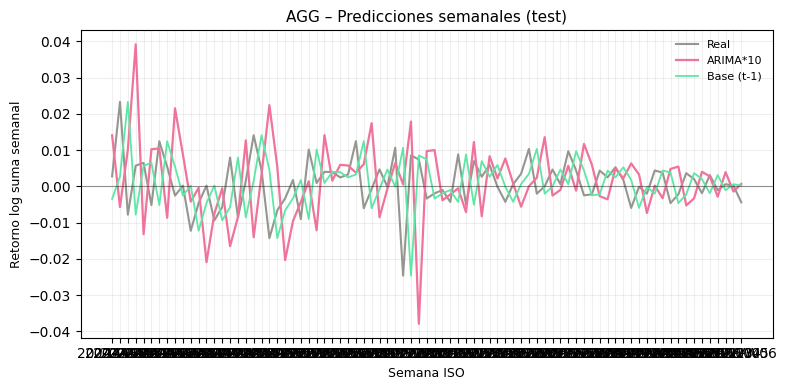

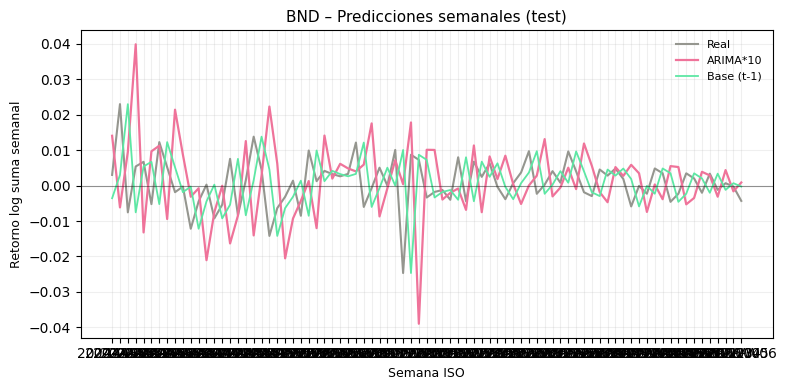

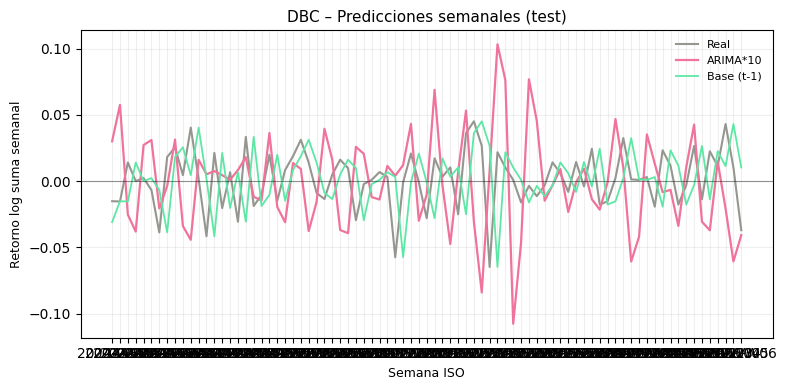

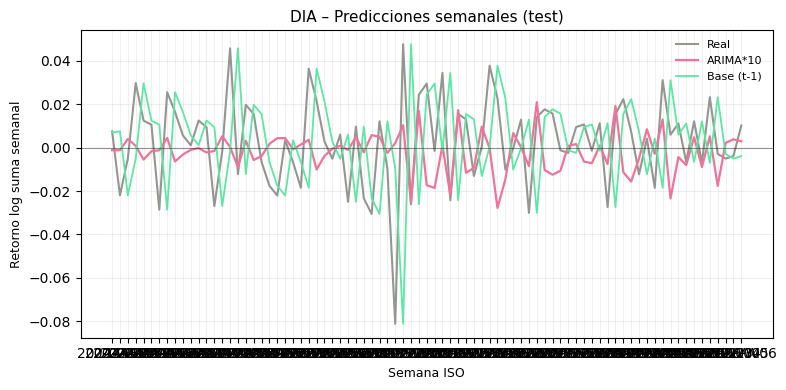

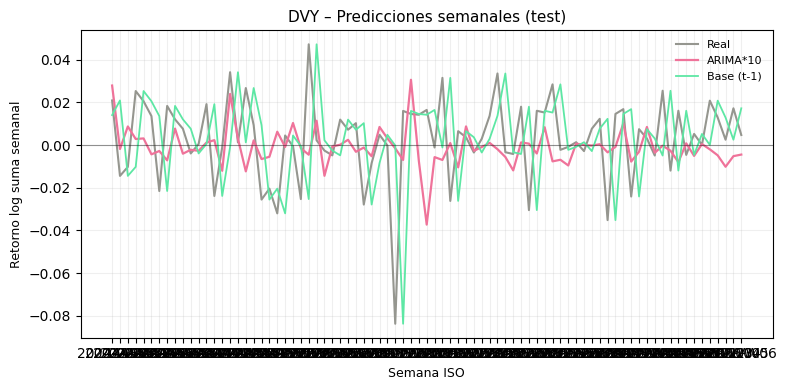

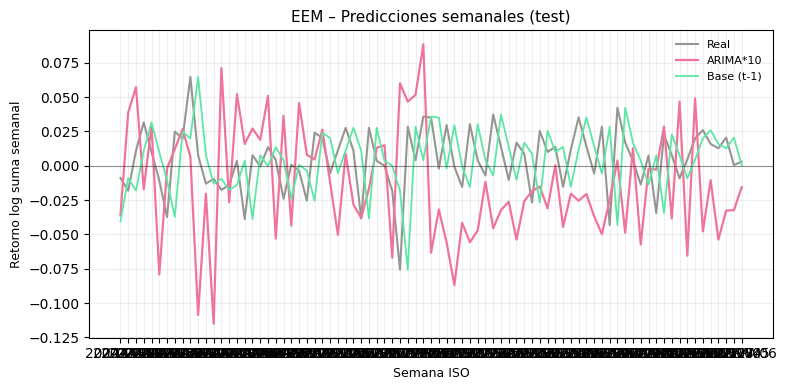

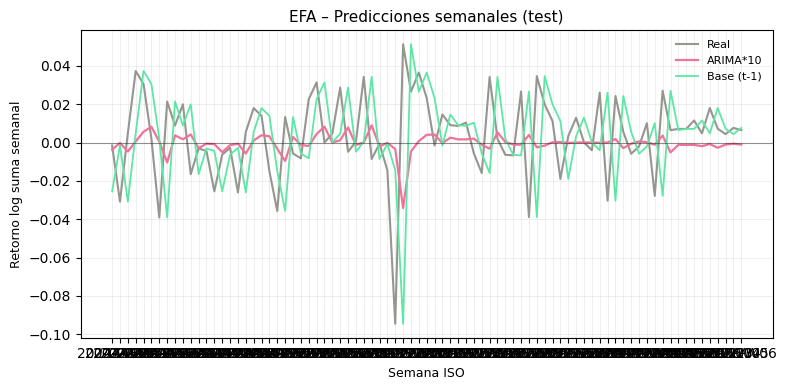

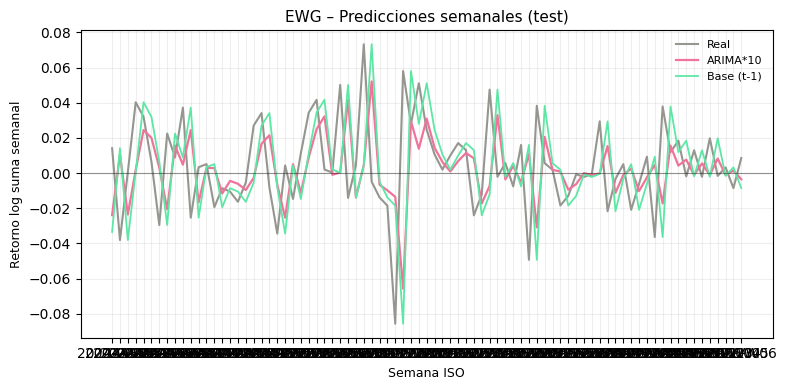

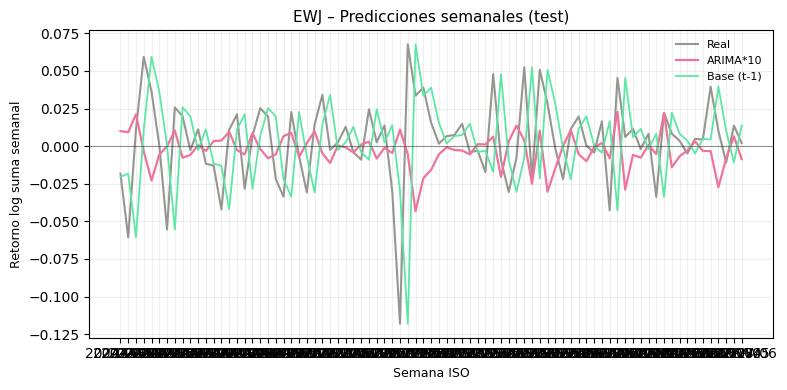

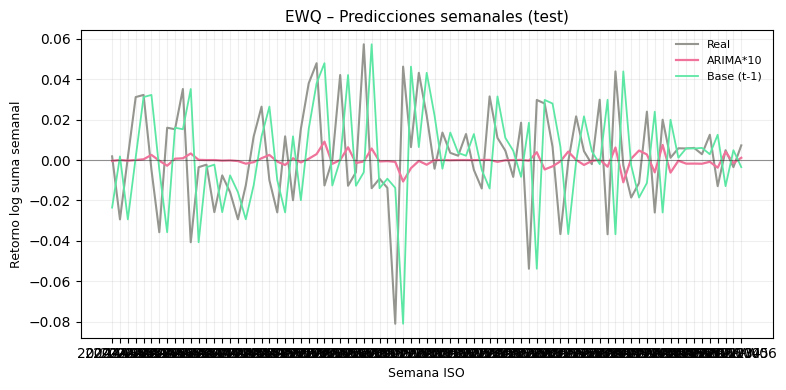

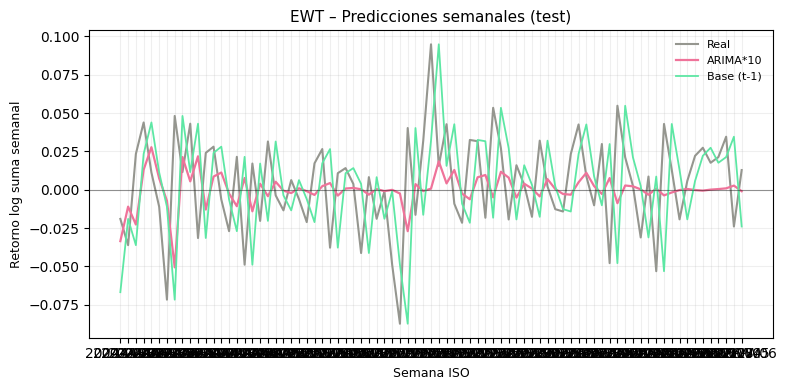

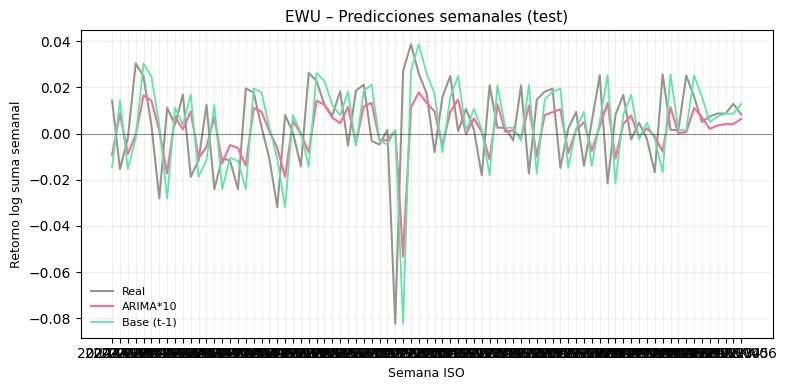

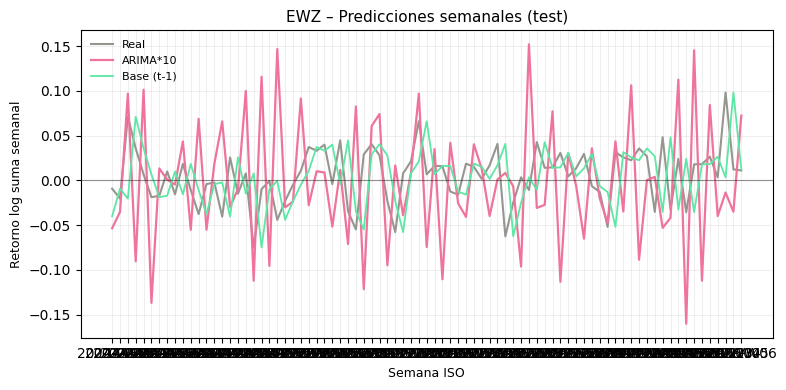

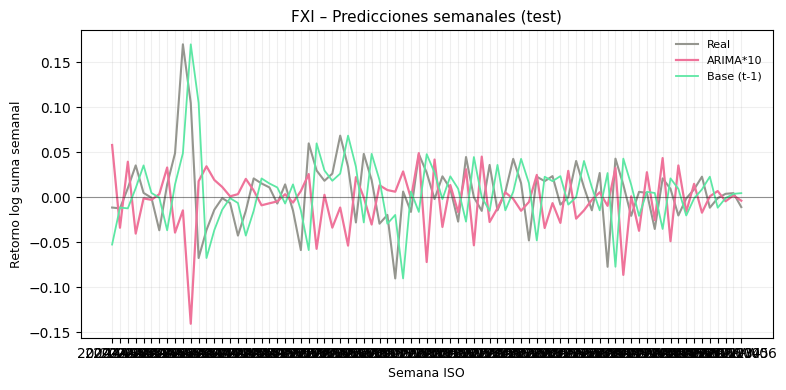

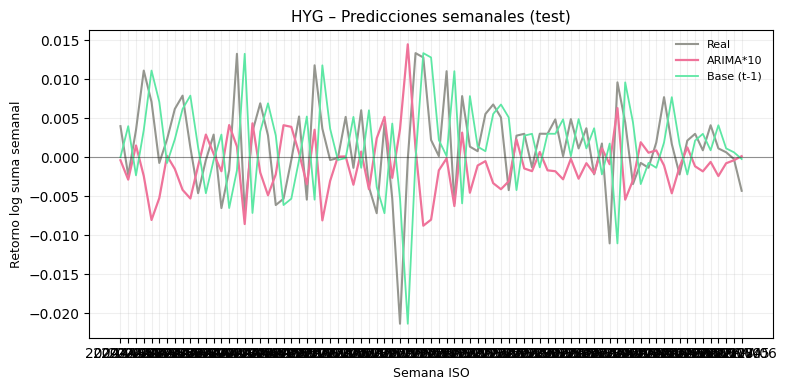

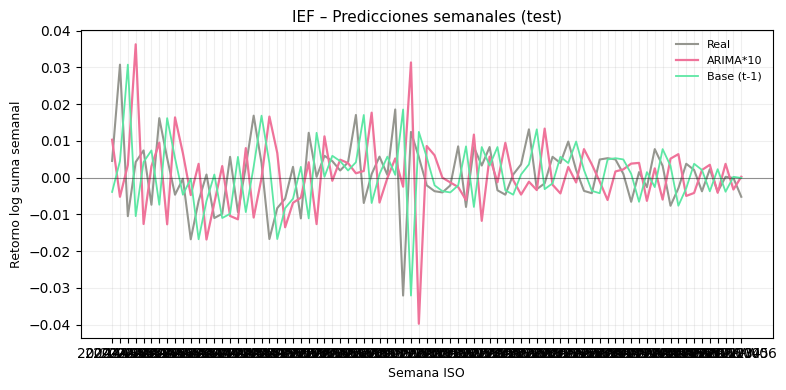

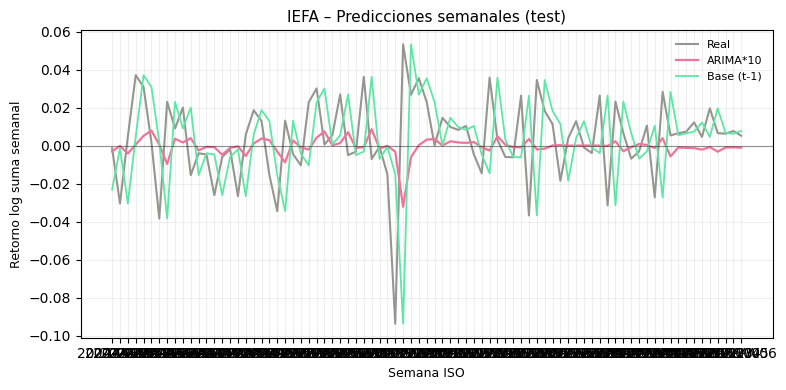

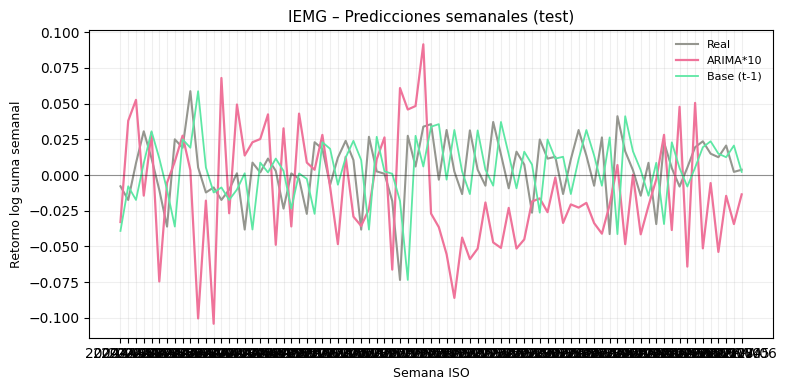

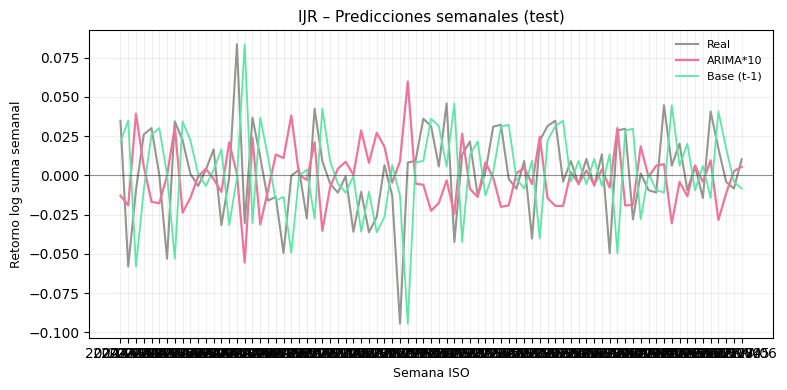

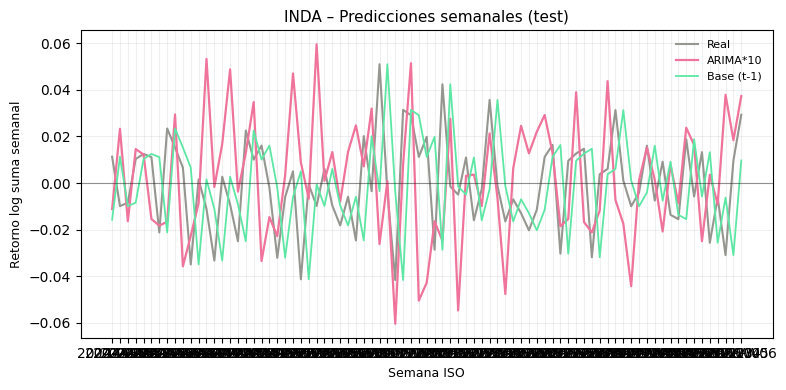

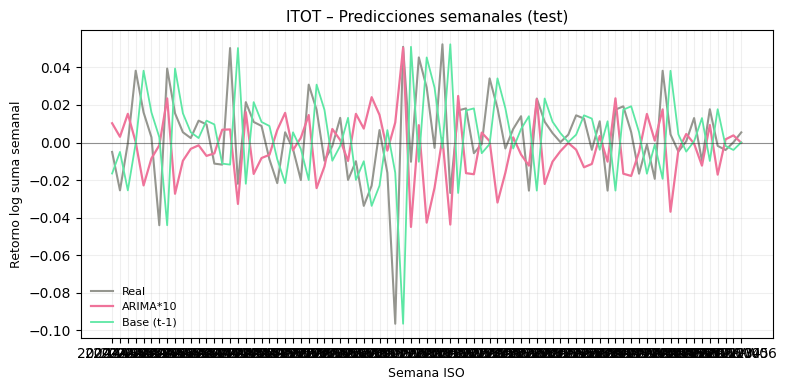

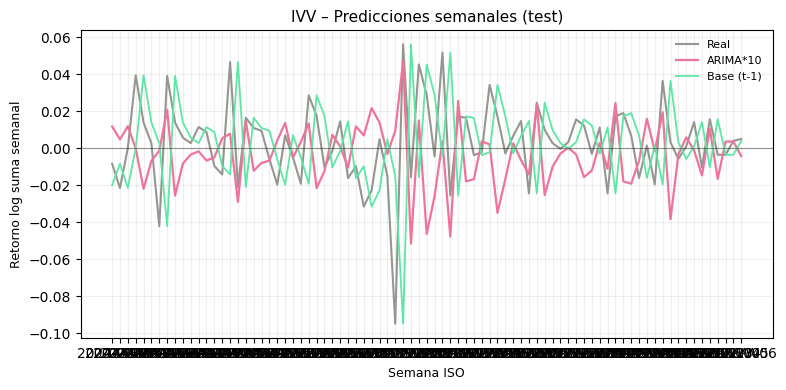

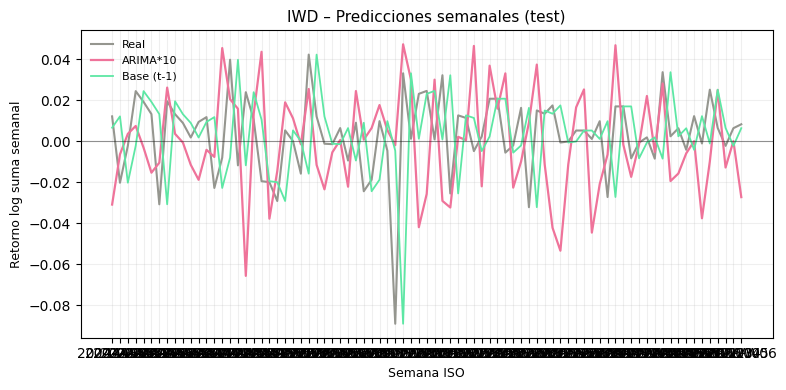

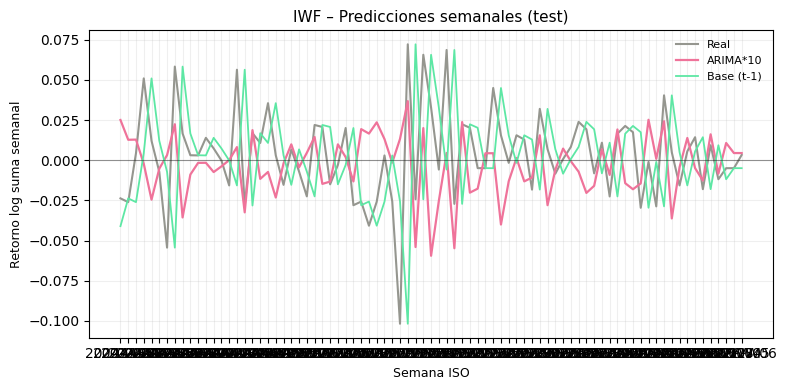

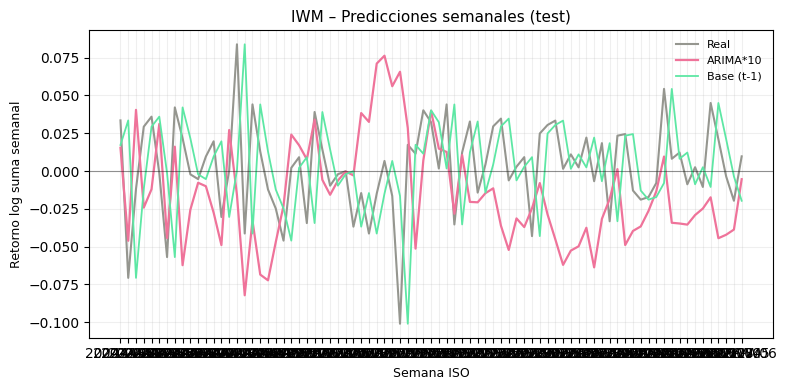

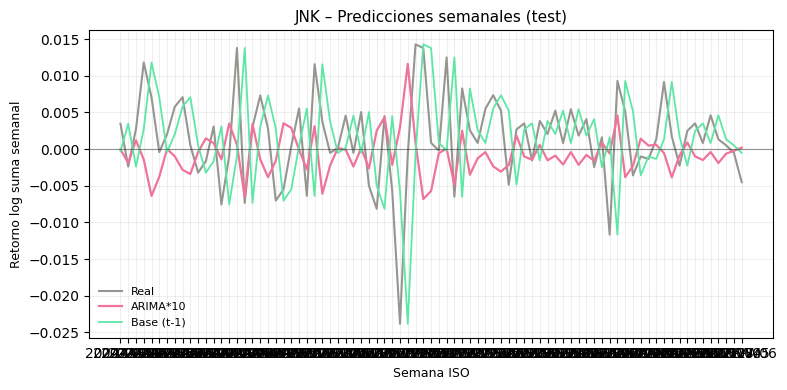

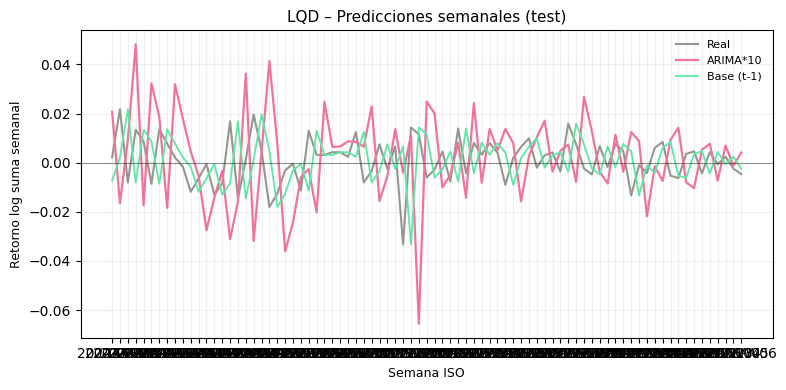

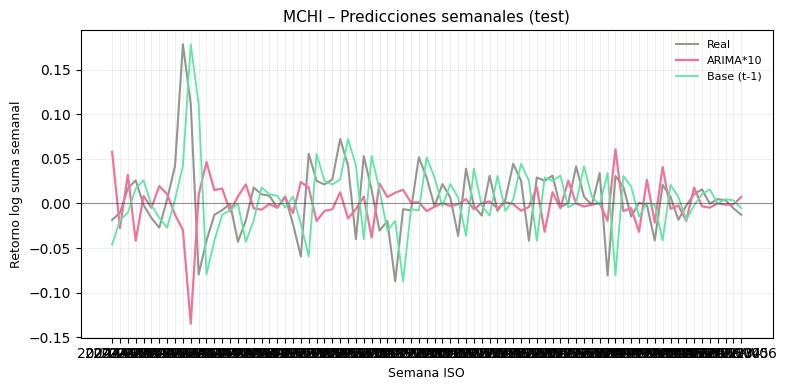

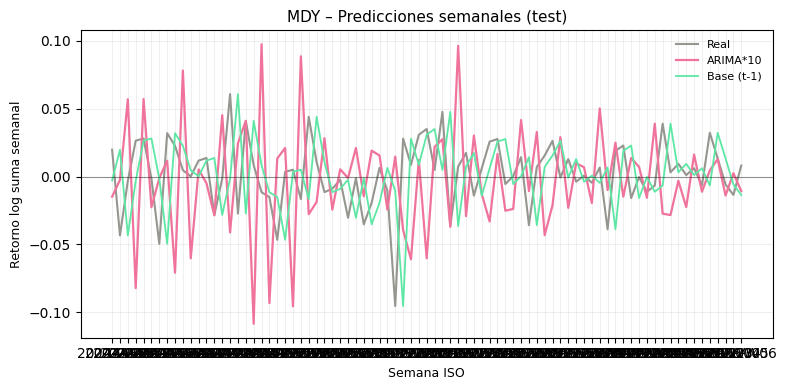

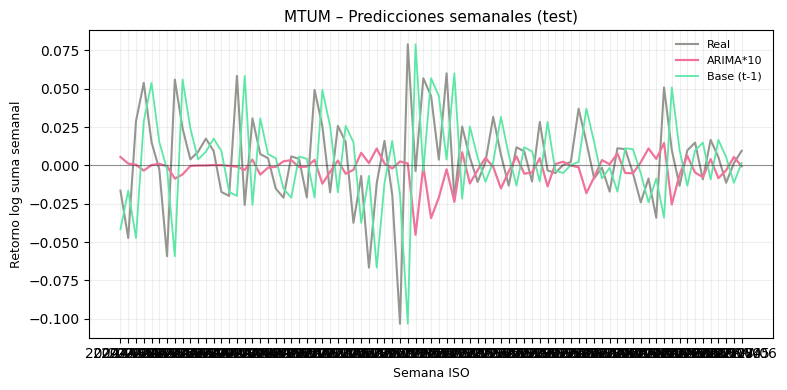

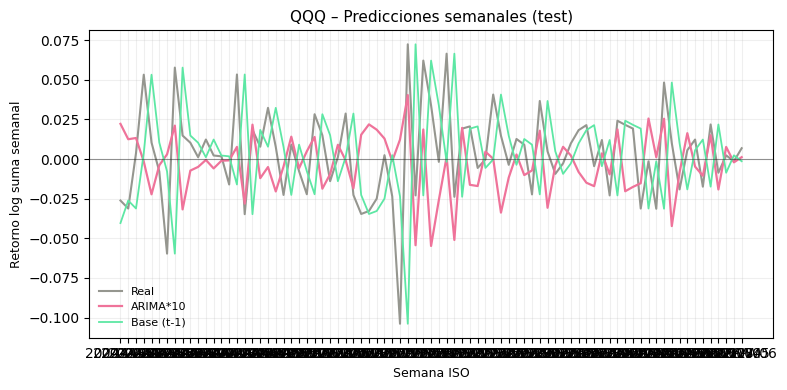

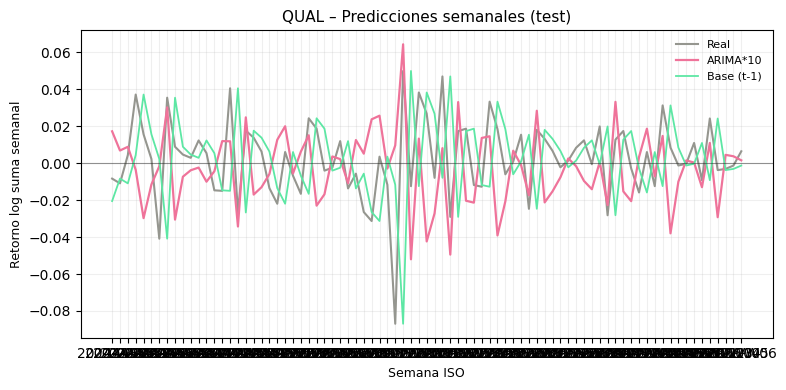

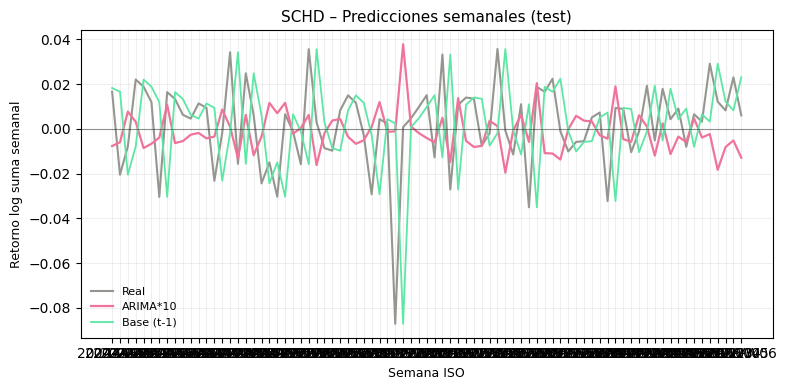

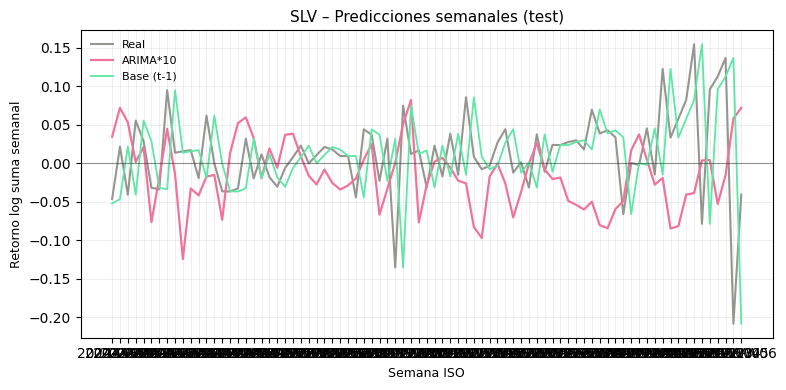

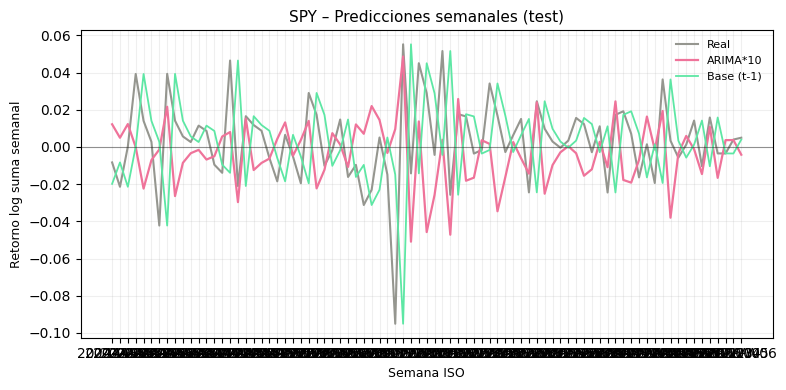

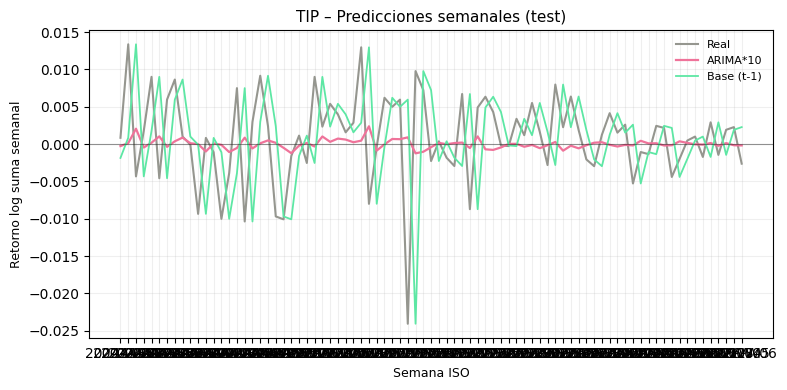

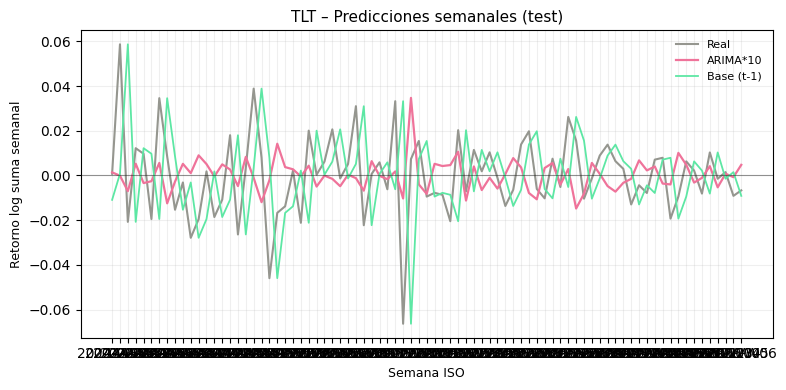

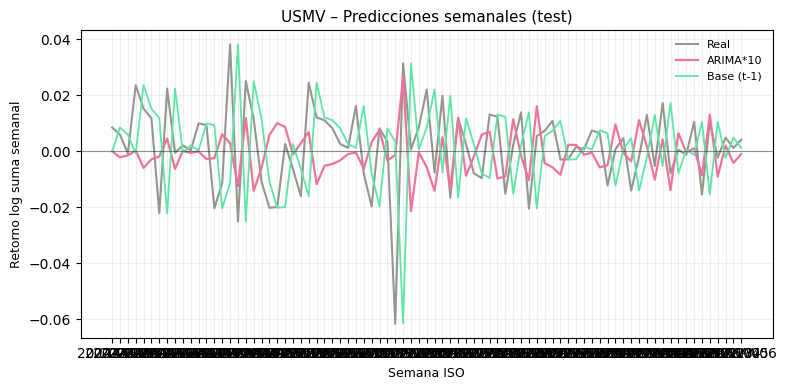

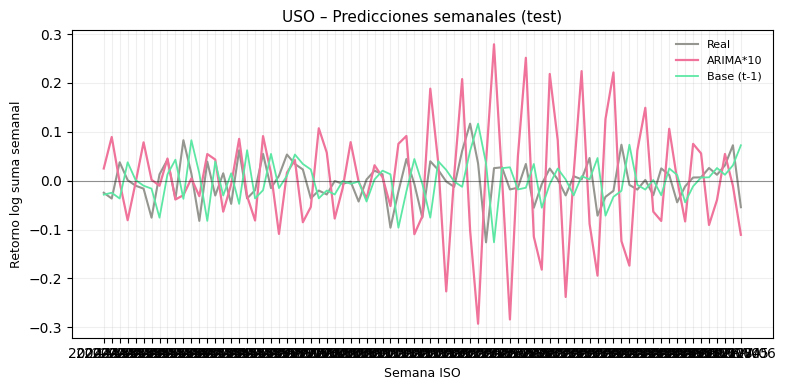

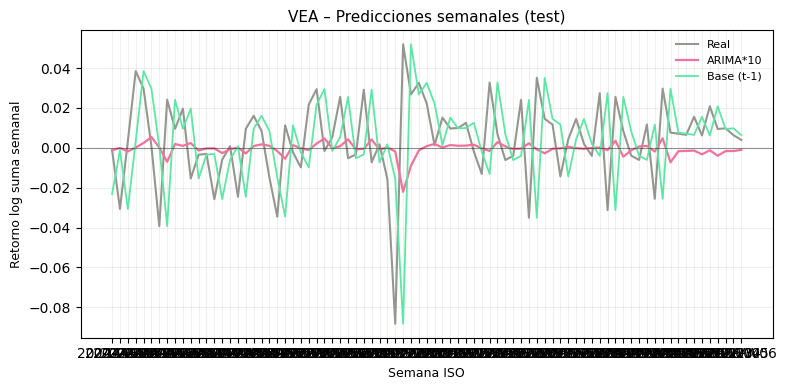

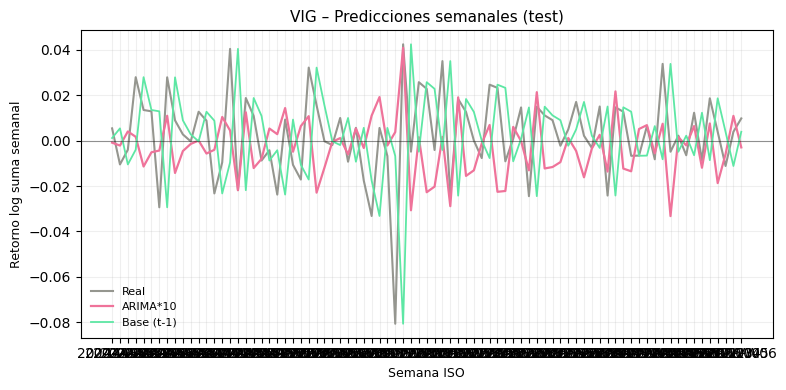

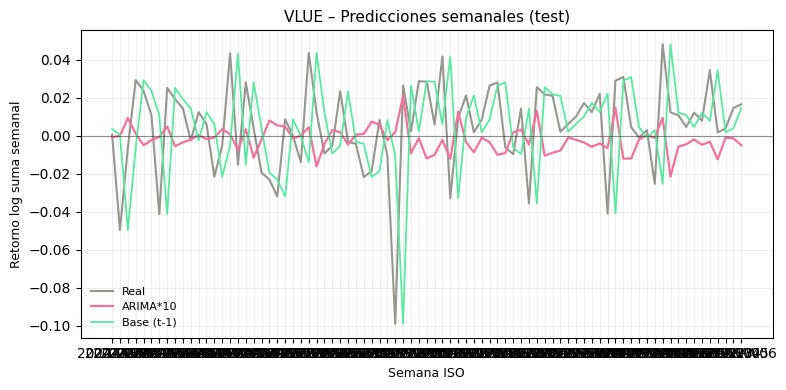

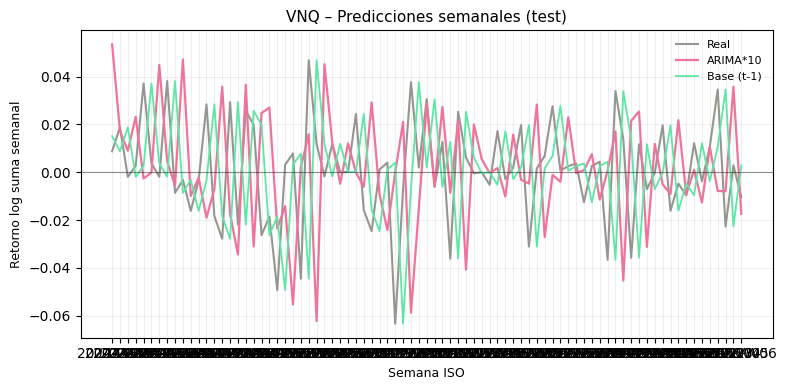

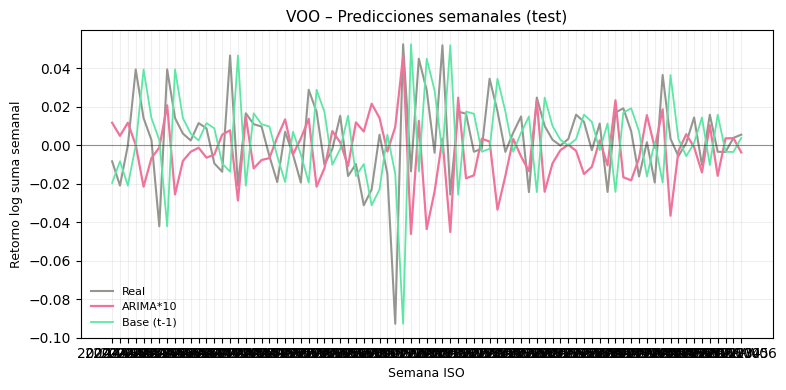

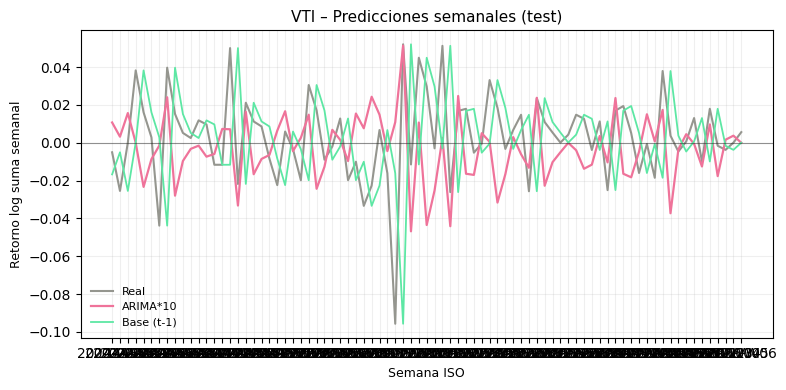

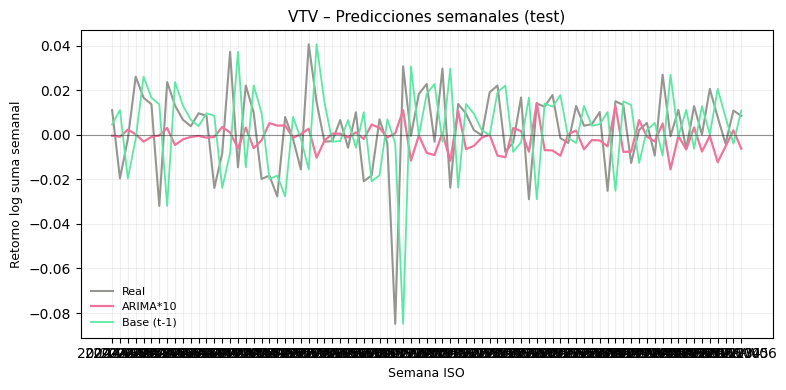

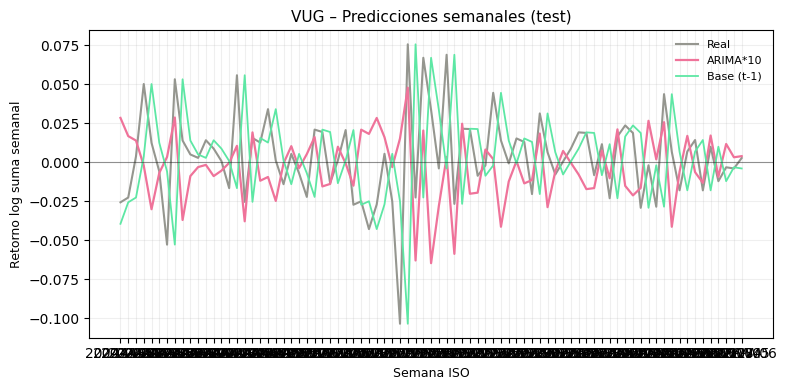

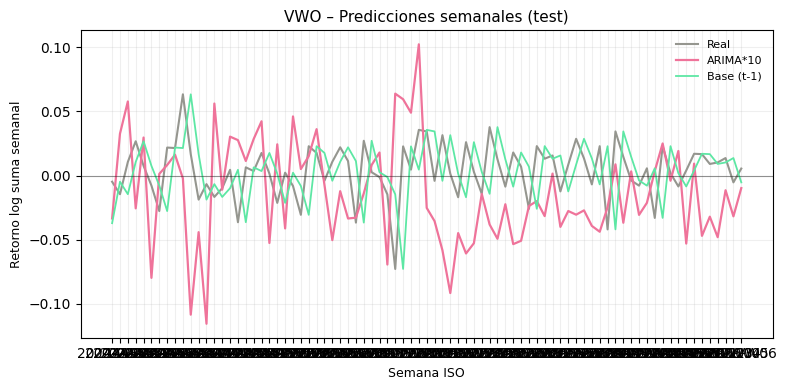

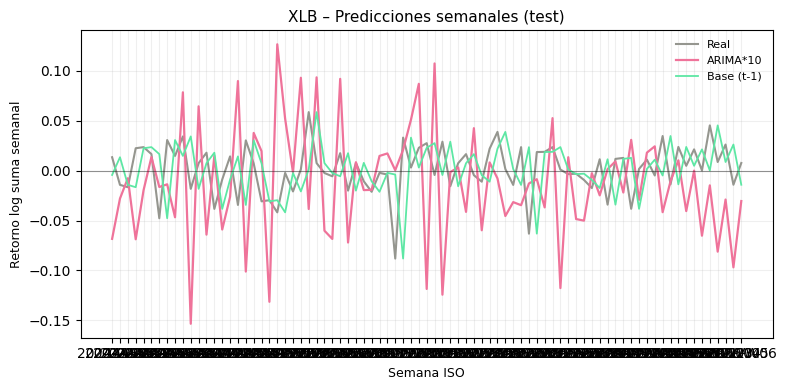

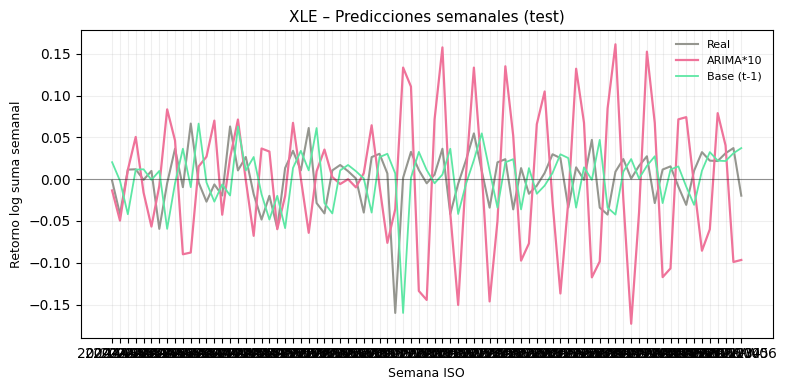

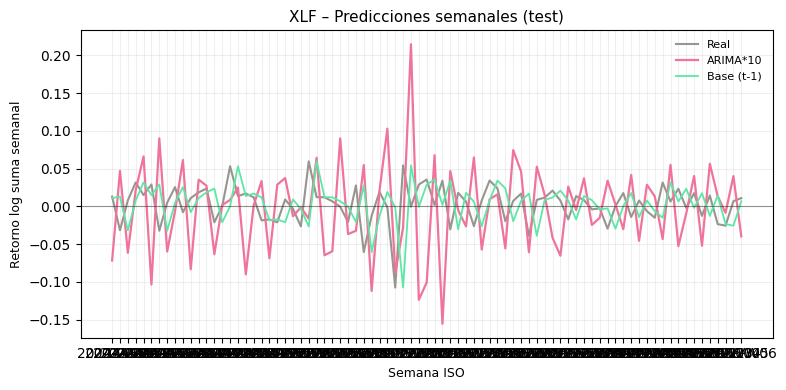

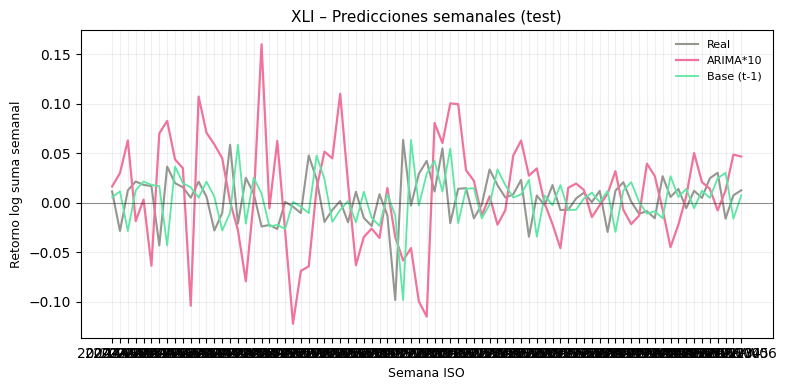

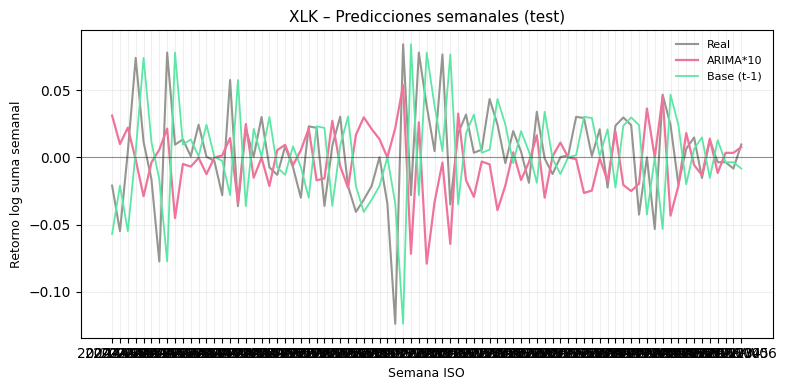

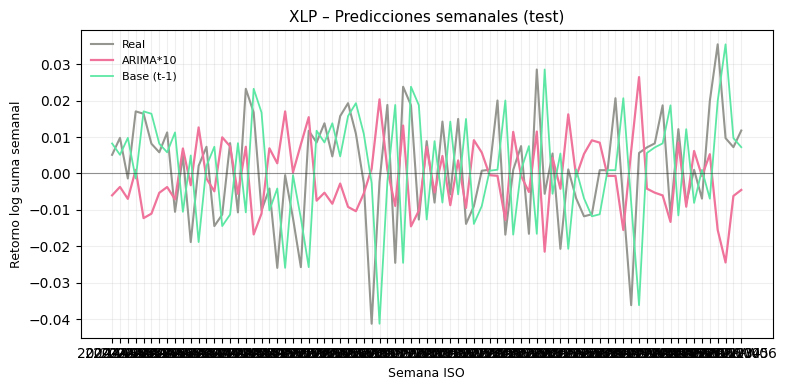

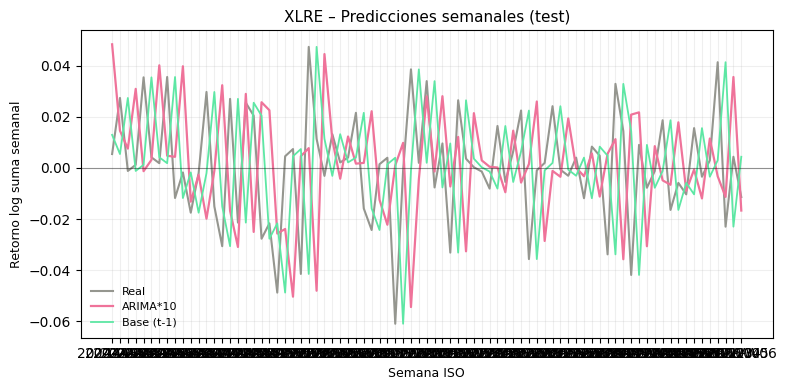

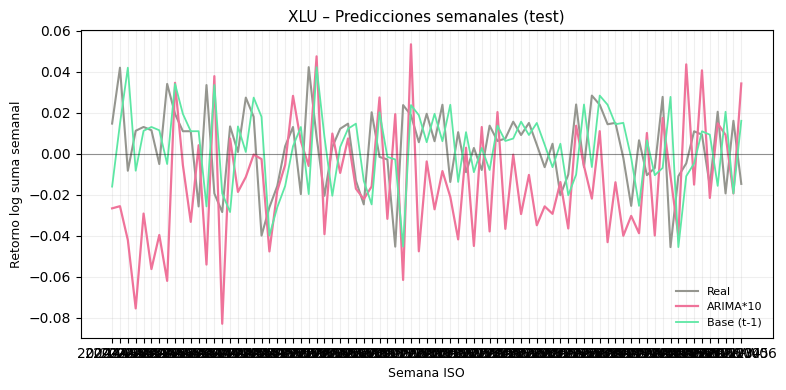

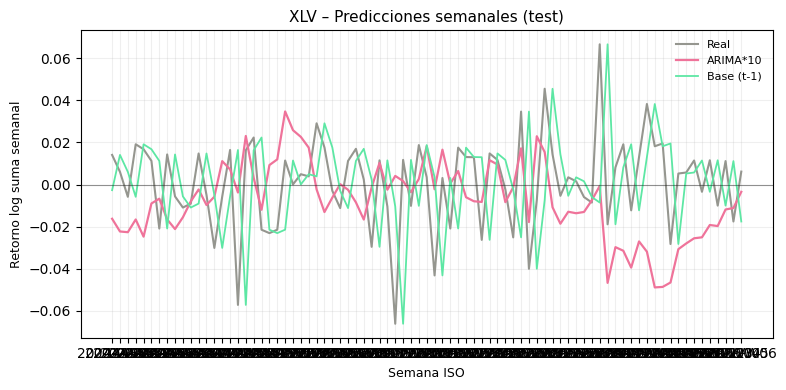

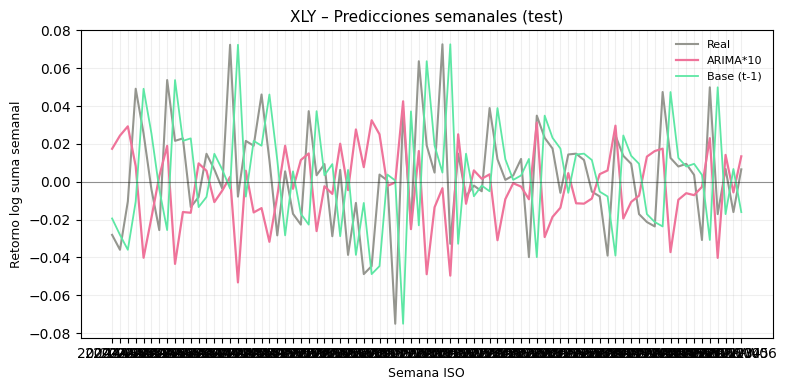

: 

: 

In [ ]:
import matplotlib.pyplot as plt

color_real  = '#95968F'
color_arima = '#EF739A'
color_base  = '#5DE7A4'

for etf, df in resultados_preds_semanal.items():

    plt.figure(figsize=(8, 4))

    plt.plot(df['real'],       label='Real',      color=color_real,  linewidth=1.5)
    plt.plot(df['arima'] * 10, label='ARIMA*10',  color=color_arima, linewidth=1.6)
    plt.plot(df['base'],       label='Base (t-1)', color=color_base,  linewidth=1.3)

    plt.axhline(0, color='black', linewidth=0.8, alpha=0.4)
    plt.title(f'{etf} – Predicciones semanales (test)', fontsize=11)
    plt.xlabel('Semana ISO', fontsize=9)
    plt.ylabel('Retorno log suma semanal', fontsize=9)
    plt.grid(alpha=0.2)
    plt.legend(fontsize=8, frameon=False)
    plt.tight_layout()
    plt.show()

### Kappa de Cohen

Se evalúa si el modelo acierta la **dirección** del movimiento semanal (sube / baja), más allá de la magnitud del error.

In [11]:
from sklearn.metrics import cohen_kappa_score, accuracy_score

metricas_direccionales_semanal = []

for etf, df in resultados_preds_semanal.items():
    real_dir  = (df['real']  > 0).astype(int)
    arima_dir = (df['arima'] > 0).astype(int)
    base_dir  = (df['base']  > 0).astype(int)

    try:
        kappa_arima = cohen_kappa_score(real_dir, arima_dir)
    except Exception:
        kappa_arima = float('nan')

    try:
        kappa_base = cohen_kappa_score(real_dir, base_dir)
    except Exception:
        kappa_base = float('nan')

    acc_arima = accuracy_score(real_dir, arima_dir)
    acc_base  = accuracy_score(real_dir, base_dir)

    metricas_direccionales_semanal.append({
        'ETF':            etf,
        'Kappa_ARIMA':    kappa_arima,
        'Kappa_BASE':     kappa_base,
        'Accuracy_ARIMA': f'{acc_arima:.2%}',
        'Accuracy_BASE':  f'{acc_base:.2%}'
    })

df_direccional_semanal = (
    pd.DataFrame(metricas_direccionales_semanal).set_index('ETF')
)
print('Analisis de Direccion Semanal (Sube/Baja):')
display(df_direccional_semanal)

Analisis de Direccion Semanal (Sube/Baja):


,Kappa_ARIMA,Kappa_BASE,Accuracy_ARIMA,Accuracy_BASE
ETF,,,,
AGG,-0.106832,-0.056522,45.68%,48.15%
BND,-0.077994,0.000000,46.91%,50.62%
DBC,-0.059629,-0.064456,46.91%,48.15%
DIA,0.199940,-0.207453,59.26%,40.74%
DVY,0.134065,-0.097419,54.32%,48.15%
EEM,0.051414,-0.077897,49.38%,49.38%
EFA,0.026442,0.194934,50.62%,61.73%
EWG,-0.049352,-0.027855,48.15%,49.38%
EWJ,-0.016934,-0.001903,46.91%,51.85%


In [12]:
etfs_nuevos = [etf for etf in resultados_preds_semanal if etf not in etfs_ya_calculados]

if not etfs_nuevos:
    print(f'Todos los ETFs ya estaban en el CSV ({len(etfs_ya_calculados)} ETFs)')
else:
    rows_preds = []
    for etf in etfs_nuevos:
        df_etf = resultados_preds_semanal[etf]
        order  = mejores_modelos_semanal[etf]['order']

        for semana in df_etf.index:
            val_real   = float(df_etf.loc[semana, 'real'])
            pred_arima = float(df_etf.loc[semana, 'arima'])
            pred_base  = float(df_etf.loc[semana, 'base'])

            rows_preds.append({
                'Archivo':        'adj_close.csv',
                'Metodo':         'ARIMA',
                'Target':         etf,
                'RMSE':           round(abs(val_real - pred_arima), 8),
                'RMSE_baseline':  round(abs(val_real - pred_base),  8),
                'RMSE_zeros':     round(abs(val_real),               8),
                'MAE':            round(abs(val_real - pred_arima), 8),
                'MAE_baseline':   round(abs(val_real - pred_base),  8),
                'MAE_zeros':      round(abs(val_real),               8),
                'Alpha':          f'ARIMA{order}',
                'Valor_Real':     round(val_real,   8),
                'Prediccion':     round(pred_arima, 8),
                'Valor_Baseline': round(pred_base,  8),
                'Valor_Zeros':    0.0,
                'Fecha_Semana':   semana
            })

    df_nuevos = pd.DataFrame(rows_preds)
    df_final  = pd.concat([df_existing, df_nuevos], ignore_index=True) if not df_existing.empty else df_nuevos
    df_final.to_csv(OUT_PREDS, index=False, encoding='utf-8-sig')

    print(f'Guardados {len(etfs_nuevos)} ETFs nuevos ({len(rows_preds)} filas)')
    print(f'Total en CSV: {len(df_final)} filas | {df_final["Target"].nunique()} ETFs')
    display(df_nuevos.head(6))


Todos los ETFs ya estaban en el CSV (58 ETFs)


In [14]:
# Guardar metricas direccionales (ya calculadas arr
#iba)
out_dir = '../../Datos_csv/Prueba_direccional_arima_semanal.csv'
df_direccional_semanal.to_csv(out_dir)
print(f'Direccional guardado en: {out_dir}')

Direccional guardado en: ../../Datos_csv/Prueba_direccional_arima_semanal.csv


## Análisis de resultados — ARIMA semanal

Resumen comparativo del modelo ARIMA frente a los benchmarks BASE (naive t-1) y ZEROS, con análisis por grupo de activo y dirección del movimiento.

In [ ]:
GRUPOS_ETF = {
    'Core US':        ['SPY','IVV','VOO','QQQ','DIA','IWM','MDY','IJR','ITOT','VTI'],
    'Factores':       ['MTUM','QUAL','USMV','VLUE','IWF','IWD','VUG','VTV','VIG','DVY','SCHD'],
    'Sectores':       ['XLK','XLF','XLV','XLY','XLP','XLE','XLI','XLB','XLU','XLRE','VNQ'],
    'Internacional':  ['EFA','IEFA','VEA','EEM','IEMG','VWO','EWJ','EWG','EWQ','EWU','EWT','EWZ','FXI','MCHI','INDA'],
    'Renta fija':     ['AGG','BND','LQD','HYG','JNK','TLT','IEF','SHY','TIP'],
    'Materias primas':['GLD','IAU','SLV','USO','DBC']
}
etf_to_grupo = {t: g for g, tickers in GRUPOS_ETF.items() for t in tickers}

df_anal = tabla_comparativa_semanal.reset_index()
df_anal['Grupo']         = df_anal['ETF'].map(etf_to_grupo).fillna('Otros')
df_anal['Mejora_vs_base']  = (df_anal['RMSE_BASE']  - df_anal['RMSE_ARIMA']) / df_anal['RMSE_BASE']  * 100
df_anal['Mejora_vs_zeros'] = (df_anal['RMSE_ZEROS'] - df_anal['RMSE_ARIMA']) / df_anal['RMSE_ZEROS'] * 100
df_anal['Bate_base']  = (df_anal['RMSE_ARIMA'] < df_anal['RMSE_BASE']).astype(int)
df_anal['Bate_zeros'] = (df_anal['RMSE_ARIMA'] < df_anal['RMSE_ZEROS']).astype(int)

tabla_global = pd.DataFrame({
    'RMSE': [df_anal['RMSE_ARIMA'].mean(), df_anal['RMSE_BASE'].mean(),  df_anal['RMSE_ZEROS'].mean()],
    'MAE':  [df_anal['MAE_ARIMA'].mean(),  df_anal['MAE_BASE'].mean(),   df_anal['MAE_ZEROS'].mean()],
}, index=['ARIMA', 'BASE', 'ZEROS'])

print('Media global — ARIMA semanal')
display(tabla_global.style.format('{:.6f}').highlight_min(color='green', axis=0))

Media global — ARIMA semanal


,RMSE,MAE
ARIMA,0.022988,0.017298
BASE,0.033733,0.025293
ZEROS,0.022790,0.017142


: 

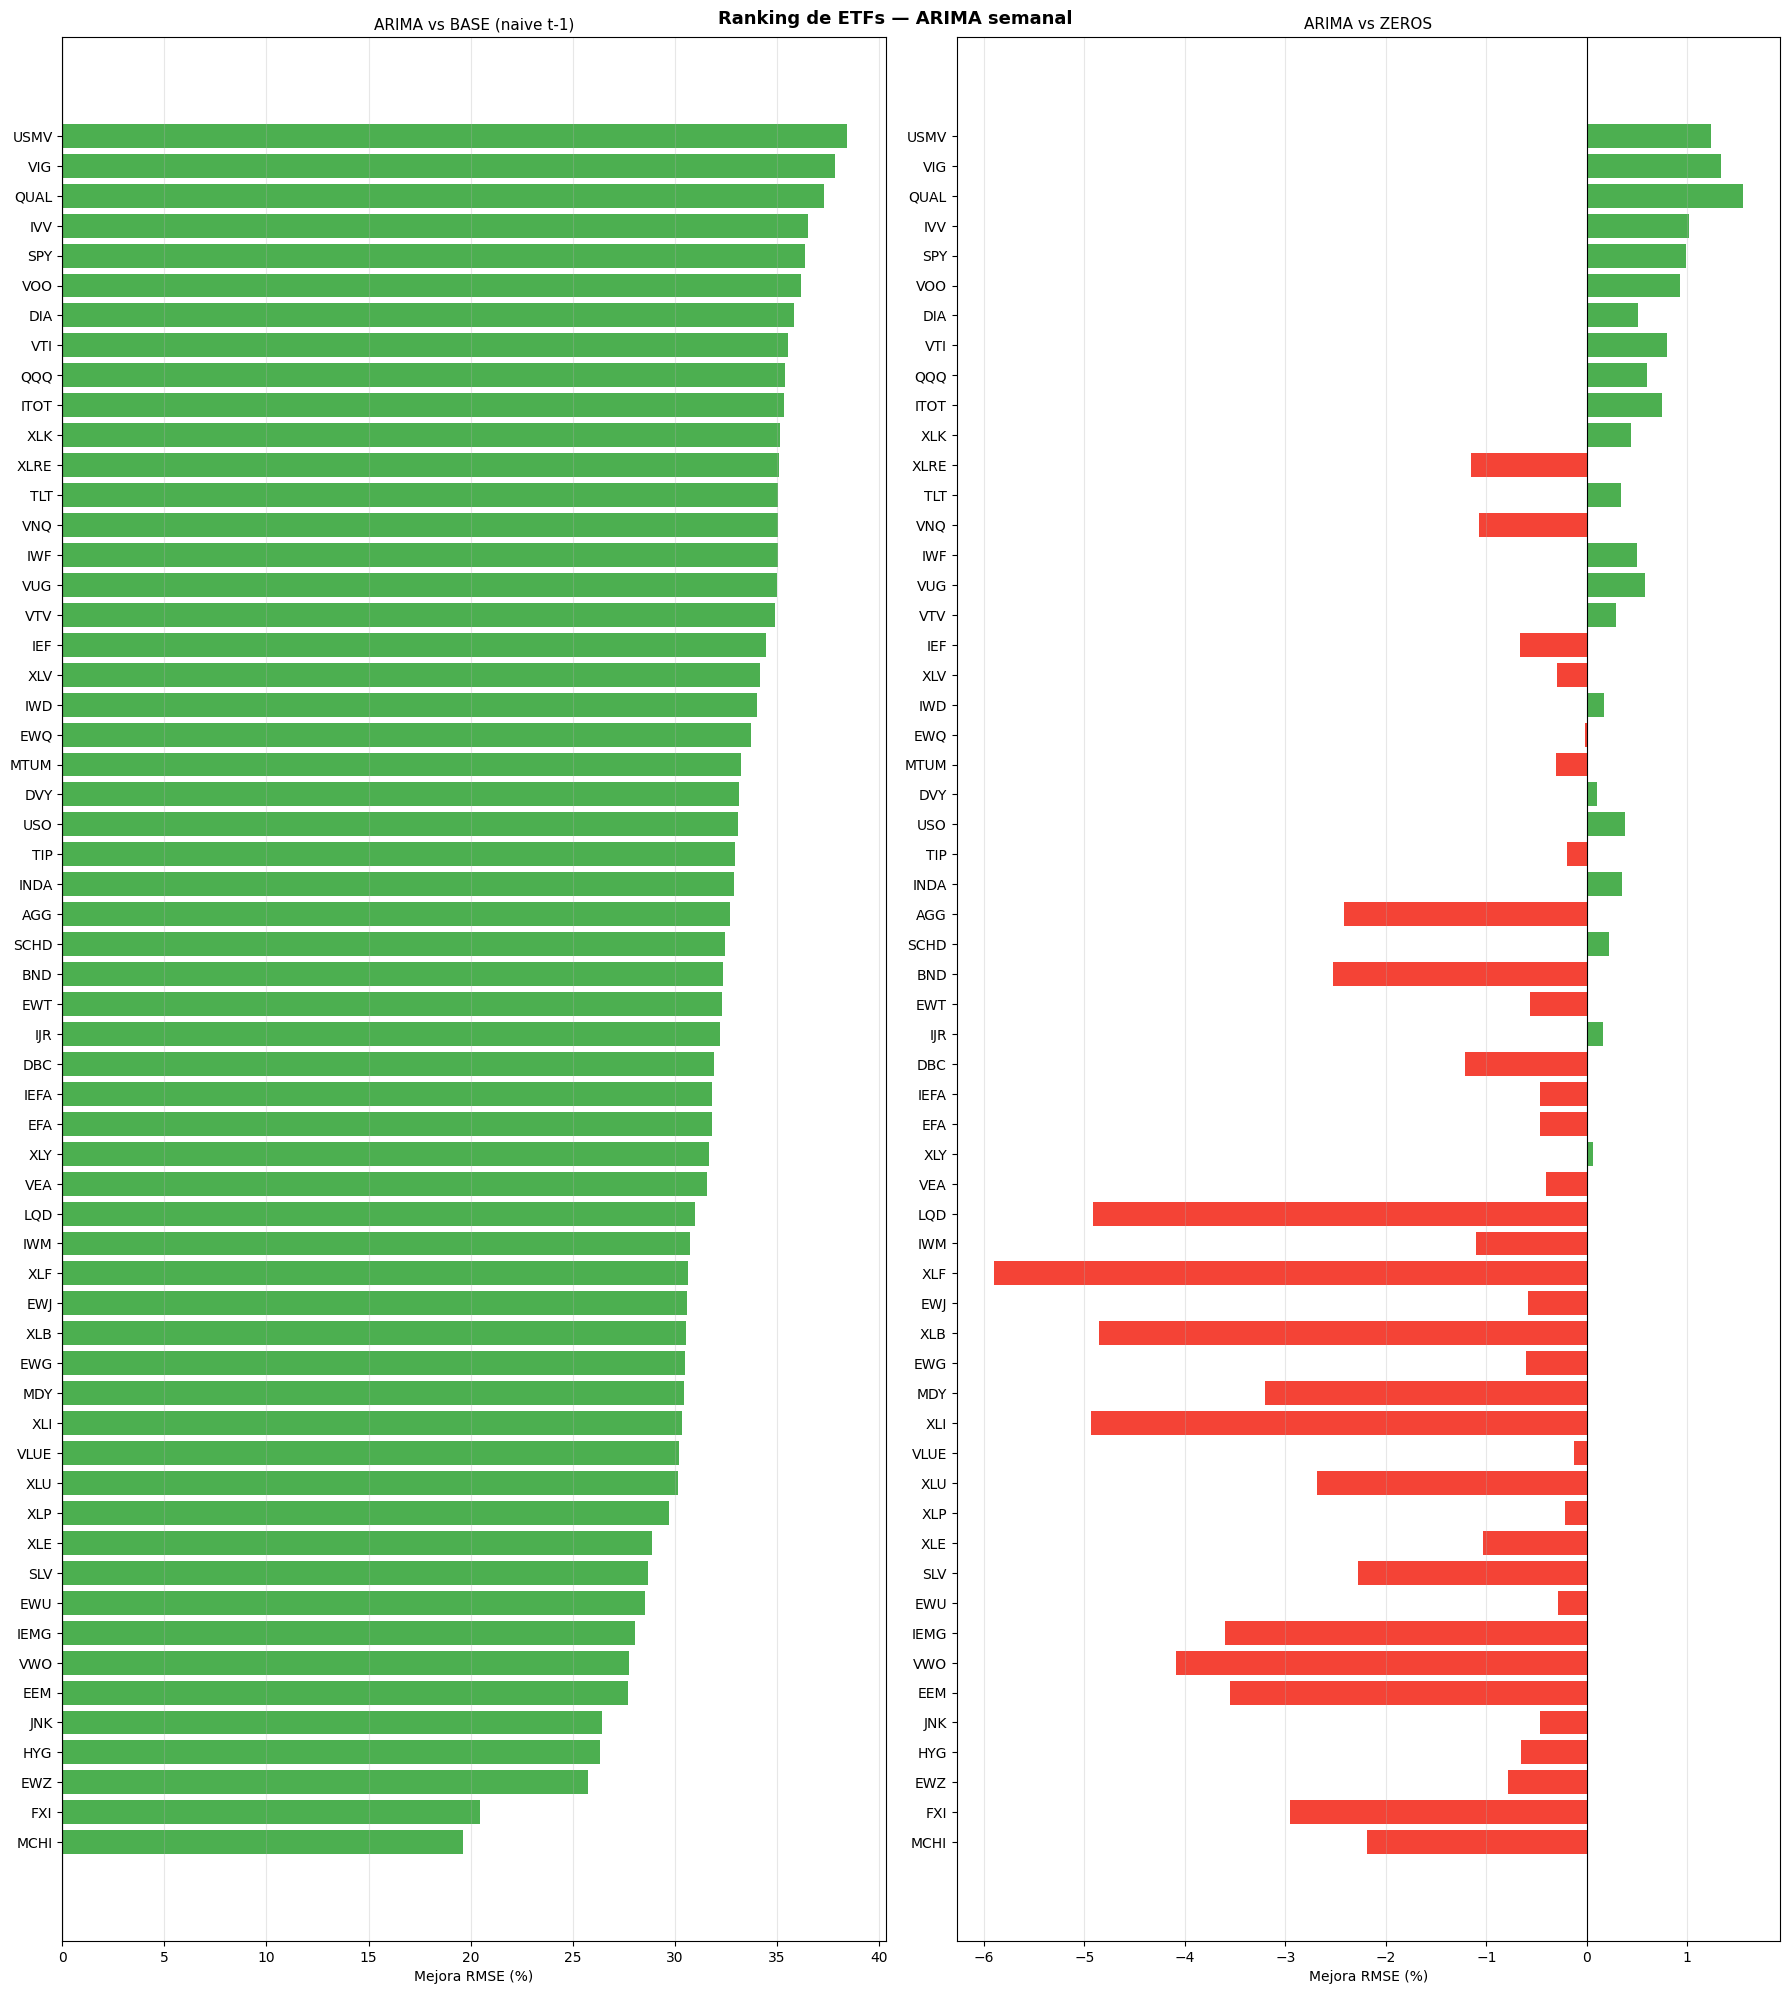

: 

In [ ]:
df_sorted = df_anal.sort_values('Mejora_vs_base')
fig, axes = plt.subplots(1, 2, figsize=(18, max(8, len(df_anal) * 0.35)))

for ax, col, titulo in zip(
    axes,
    ['Mejora_vs_base', 'Mejora_vs_zeros'],
    ['ARIMA vs BASE (naive t-1)', 'ARIMA vs ZEROS']
):
    colores = ['#4CAF50' if v >= 0 else '#F44336' for v in df_sorted[col]]
    ax.barh(df_sorted['ETF'], df_sorted[col], color=colores)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Mejora RMSE (%)')
    ax.set_title(titulo, fontsize=11)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Ranking de ETFs — ARIMA semanal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
df_dir_res = df_direccional_semanal.copy().reset_index()
df_dir_res['Kappa_ARIMA'] = pd.to_numeric(df_dir_res['Kappa_ARIMA'], errors='coerce')
df_dir_res['Kappa_BASE']  = pd.to_numeric(df_dir_res['Kappa_BASE'],  errors='coerce')
acc_arima = df_dir_res['Accuracy_ARIMA'].str.replace('%', '').astype(float)
acc_base  = df_dir_res['Accuracy_BASE'].str.replace('%', '').astype(float)

print(f'Kappa medio ARIMA : {df_dir_res["Kappa_ARIMA"].mean():.4f}')
print(f'Kappa medio BASE  : {df_dir_res["Kappa_BASE"].mean():.4f}')
print(f'Accuracy media ARIMA: {acc_arima.mean():.2f}%')
print(f'Accuracy media BASE : {acc_base.mean():.2f}%')

Kappa medio ARIMA : 0.0280
Kappa medio BASE  : -0.0473
Accuracy media ARIMA: 50.32%
Accuracy media BASE : 49.34%


: 

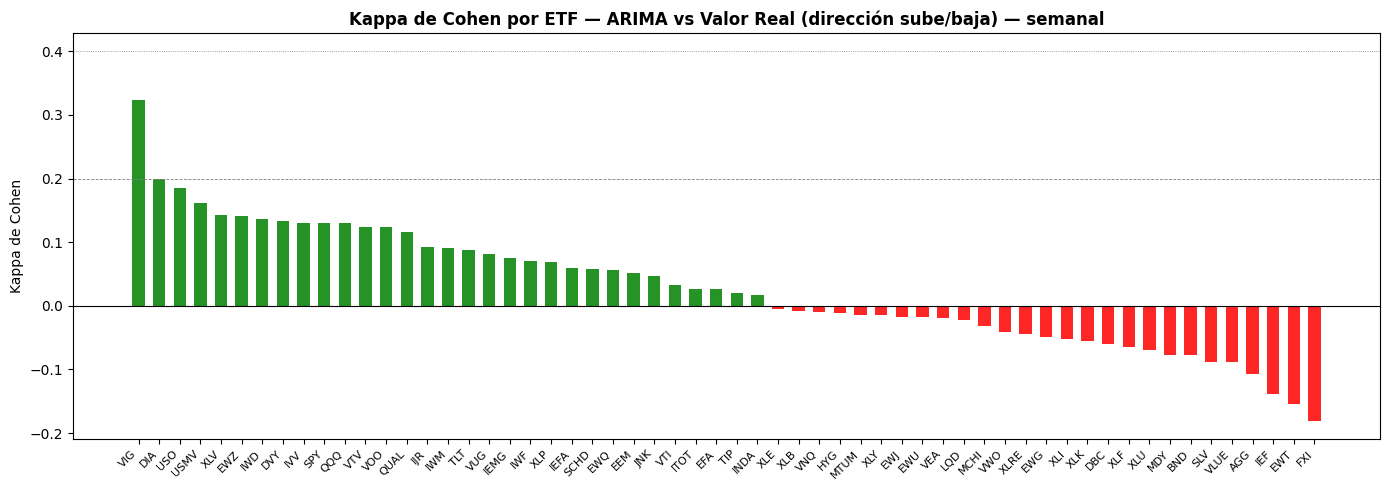

: 

In [ ]:
df_plot_kappa = df_dir_res.set_index('ETF').sort_values('Kappa_ARIMA', ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(df_plot_kappa))

# Verde si Kappa >= 0, rojo si Kappa < 0
colores = ['green' if v >= 0 else 'red' for v in df_plot_kappa['Kappa_ARIMA']]

ax.bar(
    list(x),
    df_plot_kappa['Kappa_ARIMA'],
    width=0.6,
    color=colores,
    alpha=0.85,
    label='ARIMA vs Real'
)

ax.axhline(0,    color='black', linewidth=0.8)
ax.axhline(0.20, color='gray',  linewidth=0.6, linestyle='--', label='Acuerdo leve (0.20)')
ax.axhline(0.40, color='gray',  linewidth=0.6, linestyle=':',  label='Acuerdo moderado (0.40)')

ax.set_xticks(list(x))
ax.set_xticklabels(df_plot_kappa.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Kappa de Cohen')
ax.set_title(
    'Kappa de Cohen por ETF — ARIMA vs Valor Real (dirección sube/baja) — semanal',
    fontweight='bold'
)

plt.tight_layout()
plt.show()

## Resumen por grupo de activos — ARIMA semanal

Primero se muestra la tabla agregada a nivel de grupo (RMSE medio, mejora vs benchmarks, cuántos ETFs baten cada benchmark). Después se despliega ETF a ETF dentro de cada grupo para ver qué activos son más o menos predecibles.

In [ ]:
ORDEN_GRUPOS = ['Core US', 'Factores', 'Sectores', 'Internacional', 'Renta fija', 'Materias primas']

# TABLA AGREGADA POR GRUPO
tabla_grupos = (
    df_anal.groupby('Grupo')
    .agg(
        N            =('ETF',            'count'),
        RMSE_ARIMA   =('RMSE_ARIMA',     'mean'),
        RMSE_BASE    =('RMSE_BASE',      'mean'),
        RMSE_ZEROS   =('RMSE_ZEROS',     'mean'),
        MAE_ARIMA    =('MAE_ARIMA',      'mean'),
        Mejora_base  =('Mejora_vs_base', 'mean'),
        Mejora_zeros =('Mejora_vs_zeros','mean'),
        Bate_base    =('Bate_base',      'sum'),
        Bate_zeros   =('Bate_zeros',     'sum'),
    )
    .reindex([g for g in ORDEN_GRUPOS if g in df_anal['Grupo'].unique()])
    .reset_index()
)
tabla_grupos['Bate_base_str']  = tabla_grupos.apply(lambda r: f'{int(r.Bate_base)}/{int(r.N)}',  axis=1)
tabla_grupos['Bate_zeros_str'] = tabla_grupos.apply(lambda r: f'{int(r.Bate_zeros)}/{int(r.N)}', axis=1)

fmt = {c: '{:.5f}' for c in ['RMSE_ARIMA','RMSE_BASE','RMSE_ZEROS','MAE_ARIMA']}
fmt.update({'Mejora_base': '{:.2f} %', 'Mejora_zeros': '{:.2f} %'})

print('POR GRUPO DE ACTIVOS')
display(
    tabla_grupos[['Grupo','N','RMSE_ARIMA','RMSE_BASE','RMSE_ZEROS',
                  'MAE_ARIMA','Mejora_base','Mejora_zeros','Bate_base_str','Bate_zeros_str']]
    .rename(columns={
        'Bate_base_str':  'Bate base',
        'Bate_zeros_str': 'Bate zeros',
        'Mejora_base':    'Mejora vs base (%)',
        'Mejora_zeros':   'Mejora vs zeros (%)',
    })
    .style.format(fmt)
    .highlight_min(subset=['RMSE_ARIMA'], color='green')
    .highlight_max(subset=['RMSE_ARIMA'], color='red')
)

POR GRUPO DE ACTIVOS


,Grupo,N,RMSE_ARIMA,RMSE_BASE,RMSE_ZEROS,MAE_ARIMA,Mejora vs base (%),Mejora vs zeros (%),Bate base,Bate zeros
0,Core US,10,0.02437,0.03710,0.02439,0.01814,34.457526,0.143725,10/10,8/10
1,Factores,11,0.02173,0.03322,0.02183,0.01621,34.692424,0.504787,11/11,9/11
2,Sectores,11,0.02474,0.03639,0.02427,0.01894,31.949058,-1.967417,11/11,2/11
3,Internacional,15,0.02606,0.03643,0.02570,0.01963,28.881111,-1.346200,15/15,1/15
4,Renta fija,8,0.00855,0.01263,0.00844,0.00643,31.410500,-1.436958,8/8,1/8
5,Materias primas,3,0.03971,0.05744,0.03926,0.02978,31.230664,-1.037075,3/3,1/3


: 

In [ ]:

# TABLA POR ETF DENTRO DE CADA GRUPO
fmt_etf = {
    'RMSE_ARIMA':    '{:.5f}',
    'RMSE_BASE':     '{:.5f}',
    'RMSE_ZEROS':    '{:.5f}',
    'MAE_ARIMA':     '{:.5f}',
    'Mejora_vs_base':  '{:.2f} %',
    'Mejora_vs_zeros': '{:.2f} %',
}

cols_etf = ['ETF','RMSE_ARIMA','RMSE_BASE','RMSE_ZEROS',
            'MAE_ARIMA','Mejora_vs_base','Mejora_vs_zeros','Bate_base','Bate_zeros']

for grupo in ORDEN_GRUPOS:
    sub = df_anal[df_anal['Grupo'] == grupo][cols_etf].sort_values('RMSE_ARIMA').reset_index(drop=True)
    if sub.empty:
        continue
    print(f'\n{grupo} ({len(sub)} ETFs)')
    display(
        sub.style
        .format(fmt_etf)
        .highlight_min(subset=['RMSE_ARIMA'], color='green')
        .highlight_max(subset=['RMSE_ARIMA'], color='red')
    )


Core US (10 ETFs)


,ETF,RMSE_ARIMA,RMSE_BASE,RMSE_ZEROS,MAE_ARIMA,Mejora_vs_base,Mejora_vs_zeros,Bate_base,Bate_zeros
0,DIA,0.02055,0.03203,0.02065,0.01592,35.85 %,0.51 %,1,1
1,VOO,0.02194,0.03437,0.02215,0.01605,36.16 %,0.92 %,1,1
2,SPY,0.02211,0.03475,0.02233,0.01608,36.38 %,0.99 %,1,1
3,IVV,0.02217,0.03492,0.02239,0.01612,36.51 %,1.01 %,1,1
4,VTI,0.02251,0.03491,0.02269,0.01640,35.52 %,0.80 %,1,1
5,ITOT,0.02263,0.03501,0.02280,0.01649,35.36 %,0.74 %,1,1
6,MDY,0.02553,0.03669,0.02473,0.01909,30.43 %,-3.20 %,1,0
7,IJR,0.02806,0.04139,0.02811,0.02130,32.20 %,0.16 %,1,1
8,QQQ,0.02823,0.04371,0.02840,0.02106,35.42 %,0.60 %,1,1
9,IWM,0.02995,0.04324,0.02962,0.02290,30.74 %,-1.10 %,1,0



Factores (11 ETFs)


,ETF,RMSE_ARIMA,RMSE_BASE,RMSE_ZEROS,MAE_ARIMA,Mejora_vs_base,Mejora_vs_zeros,Bate_base,Bate_zeros
0,USMV,0.01466,0.02380,0.01484,0.01103,38.41 %,1.24 %,1,1
1,VTV,0.01853,0.02848,0.01859,0.01401,34.92 %,0.29 %,1,1
2,VIG,0.01859,0.02990,0.01884,0.01394,37.84 %,1.34 %,1,1
3,SCHD,0.01898,0.02811,0.01902,0.01435,32.47 %,0.22 %,1,1
4,IWD,0.01934,0.02932,0.01938,0.01431,34.02 %,0.17 %,1,1
5,DVY,0.01936,0.02894,0.01938,0.01422,33.13 %,0.10 %,1,1
6,QUAL,0.02080,0.03319,0.02112,0.01545,37.33 %,1.55 %,1,1
7,VLUE,0.02400,0.03439,0.02397,0.01846,30.21 %,-0.13 %,1,0
8,VUG,0.02769,0.04261,0.02785,0.02048,35.02 %,0.58 %,1,1
9,IWF,0.02773,0.04268,0.02787,0.02064,35.04 %,0.50 %,1,1



Sectores (11 ETFs)


...


Renta fija (8 ETFs)


,ETF,RMSE_ARIMA,RMSE_BASE,RMSE_ZEROS,MAE_ARIMA,Mejora_vs_base,Mejora_vs_zeros,Bate_base,Bate_zeros
0,HYG,0.00587,0.00797,0.00583,0.00448,26.35 %,-0.66 %,1,0
1,TIP,0.00590,0.00880,0.00589,0.00440,32.93 %,-0.20 %,1,0
2,JNK,0.00623,0.00846,0.00620,0.00467,26.42 %,-0.47 %,1,0
3,BND,0.00694,0.01025,0.00677,0.00519,32.34 %,-2.53 %,1,0
4,AGG,0.00705,0.01048,0.00688,0.00527,32.72 %,-2.42 %,1,0
5,IEF,0.00883,0.01347,0.00877,0.00660,34.45 %,-0.66 %,1,0
6,LQD,0.00961,0.01393,0.00916,0.00752,31.00 %,-4.91 %,1,0
7,TLT,0.01799,0.02771,0.01806,0.01328,35.07 %,0.34 %,1,1



Materias primas (3 ETFs)


,ETF,RMSE_ARIMA,RMSE_BASE,RMSE_ZEROS,MAE_ARIMA,Mejora_vs_base,Mejora_vs_zeros,Bate_base,Bate_zeros
0,DBC,0.02181,0.03203,0.02155,0.01716,31.92 %,-1.21 %,1,0
1,USO,0.04150,0.06203,0.04165,0.03187,33.11 %,0.38 %,1,1
2,SLV,0.05583,0.07827,0.05458,0.04033,28.67 %,-2.28 %,1,0


: 

: 